In [10]:
from models.gpkg import GeoPackage
import matplotlib.pyplot as plt

In [24]:
gpkg = GeoPackage()
gdf = gpkg.read_layer('vindex_1985_2023_godmode')

In [ ]:
[f for f in gdf.columns if 'veg' in f]


['grassland_se', 'grassland_ex']

In [35]:
gdf[['mining_threat_area_ratio_se', 'mining_threat_area_ratio_ex']].sum()

mining_threat_area_ratio_se    11.460969
mining_threat_area_ratio_ex    24.564375
dtype: float64

In [ ]:
cat_count = gdf['vulnerability_category'].value_counts()

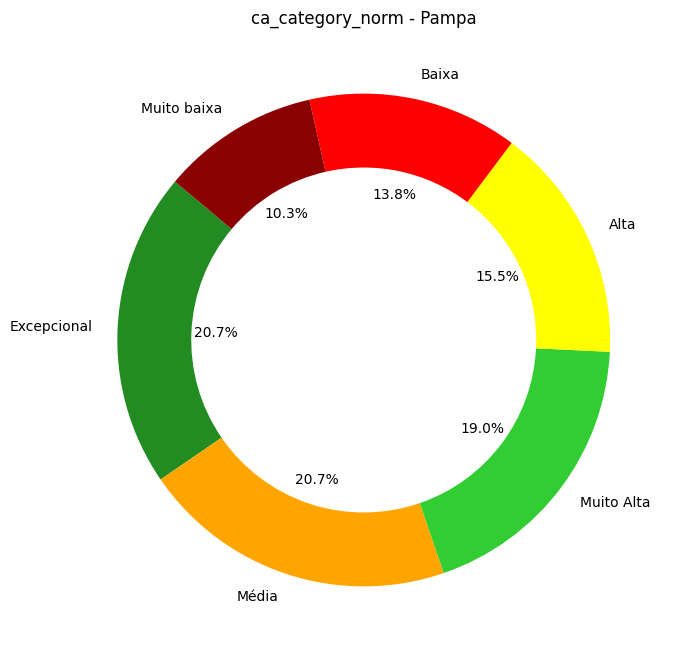

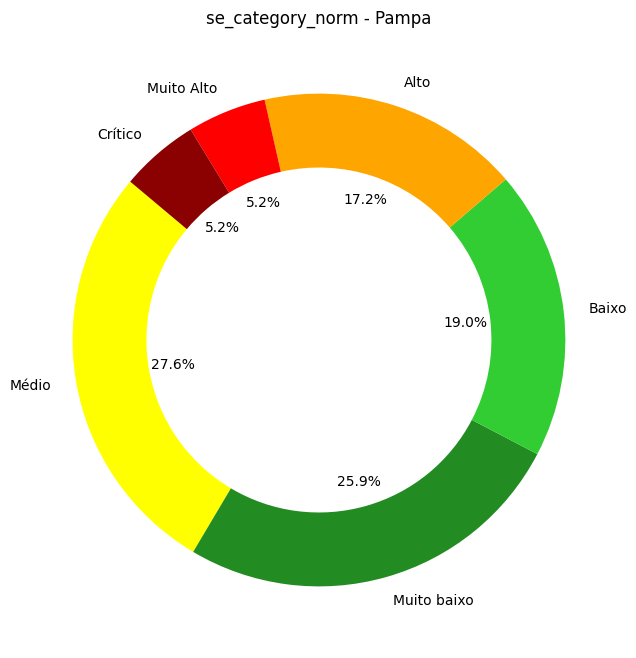

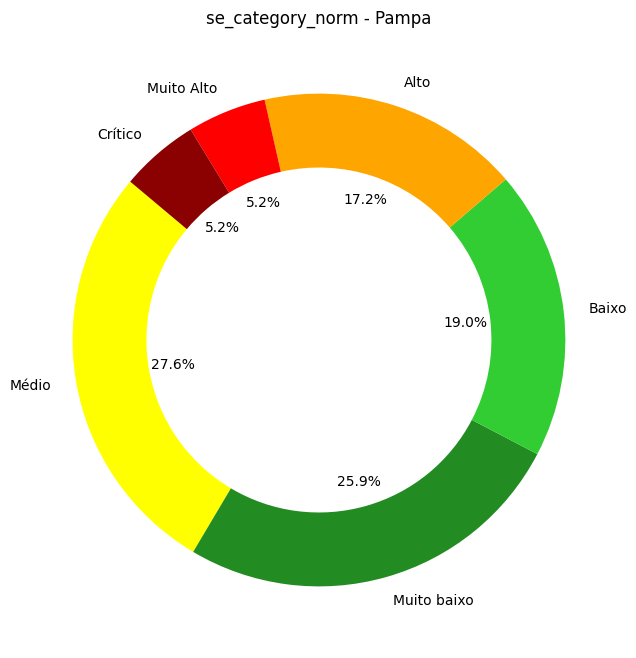

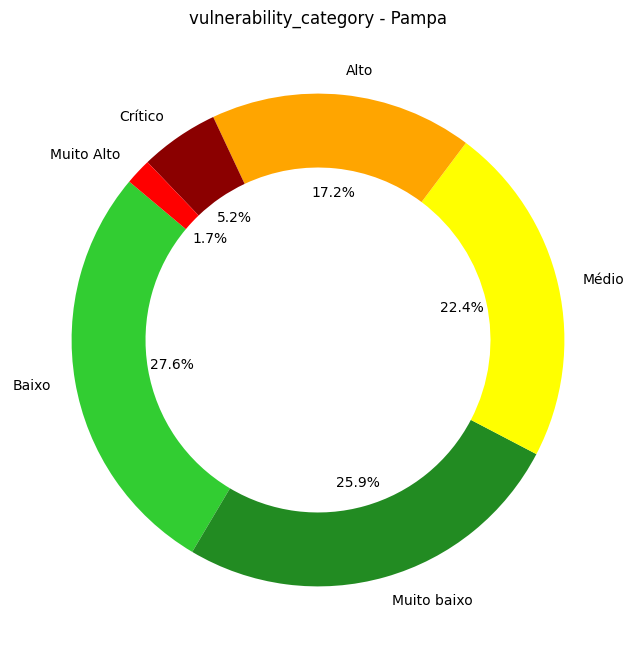

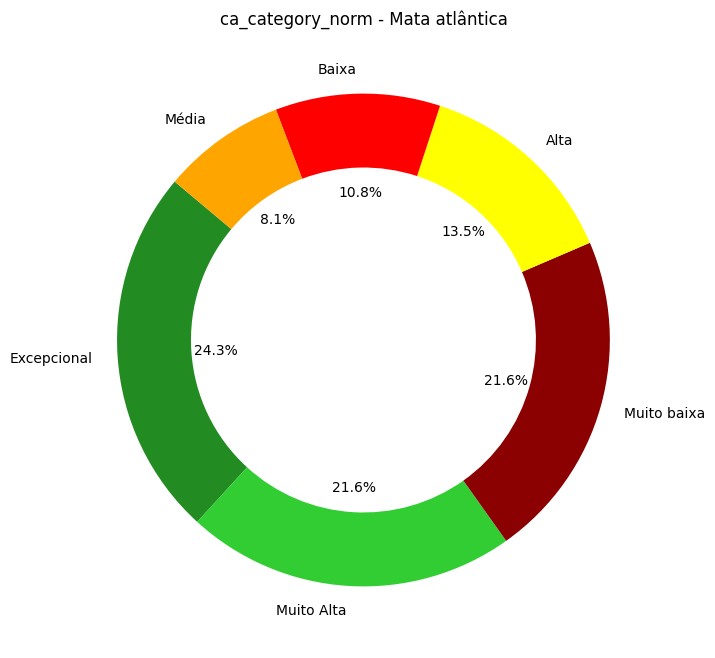

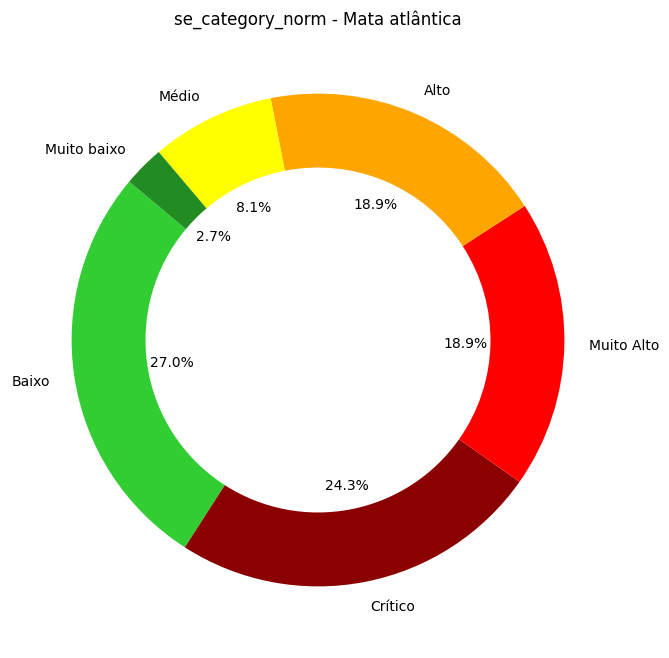

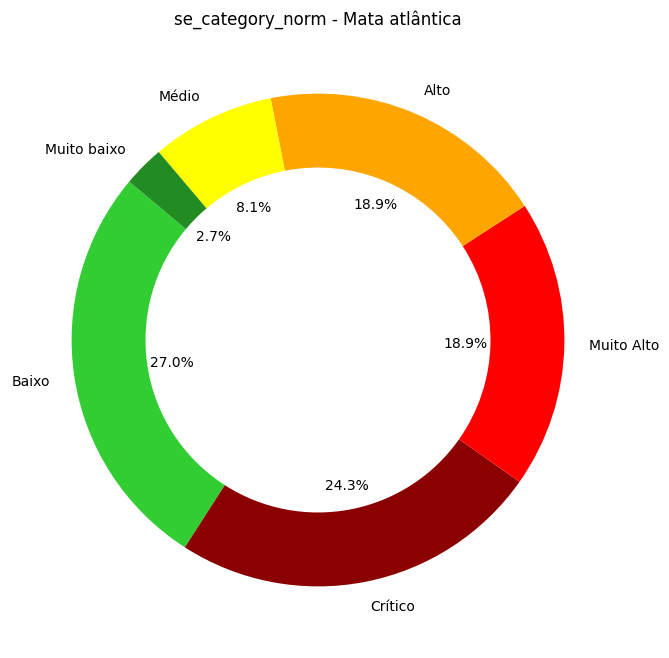

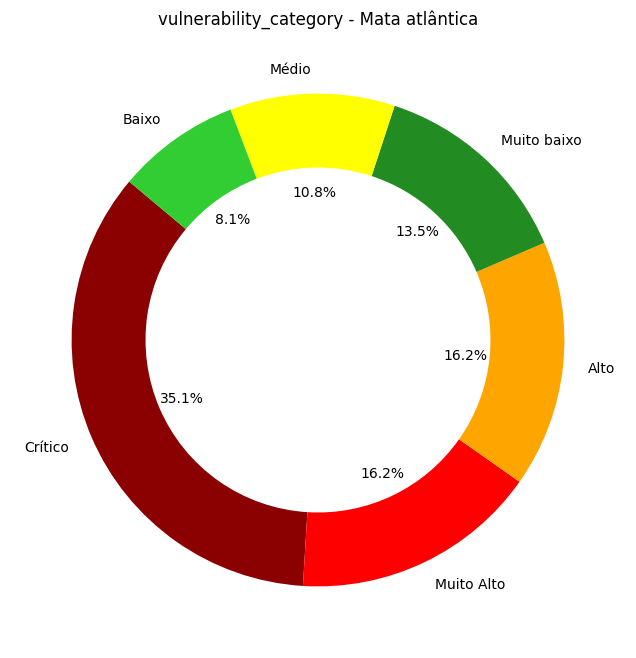

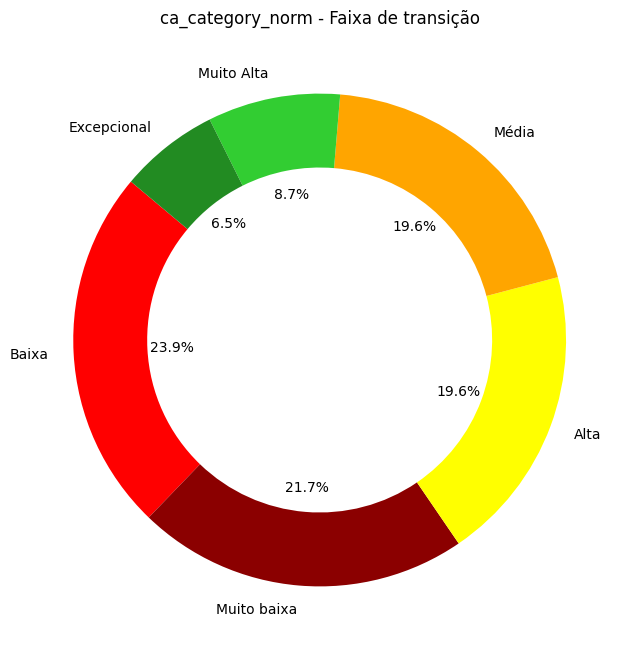

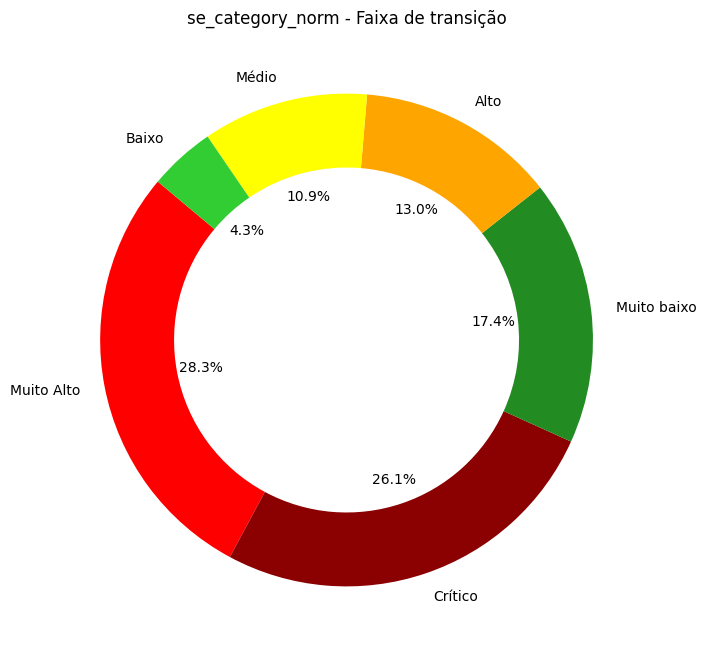

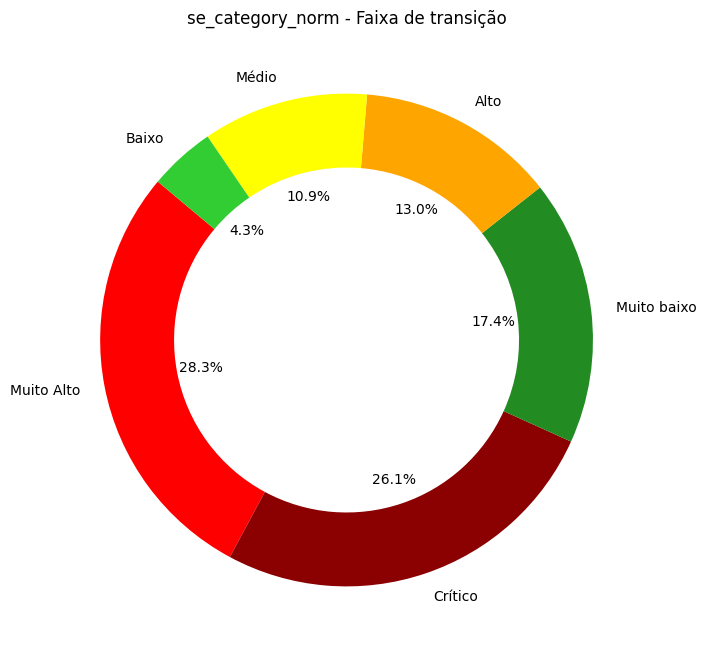

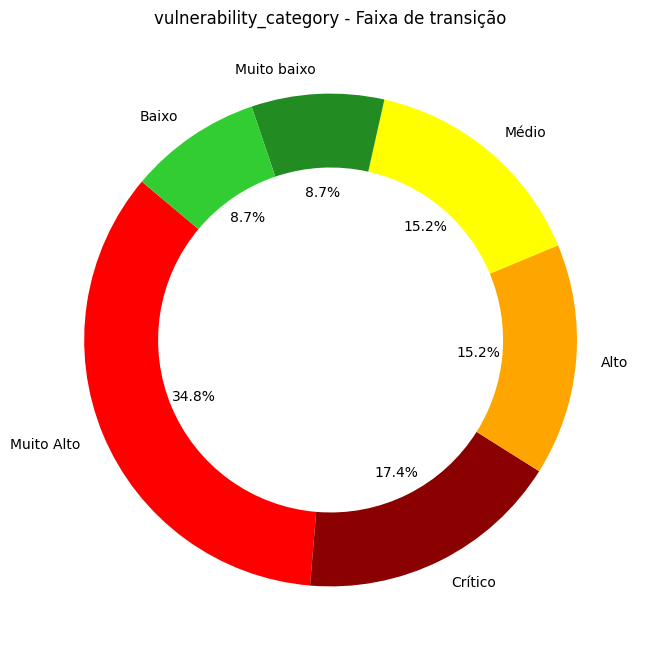

In [8]:
biomas = ['Pampa', 'Mata atlântica', 'Faixa de transição']
indices = ['ca_category_norm', 'se_category_norm', 'se_category_norm', 'vulnerability_category']
for bioma in biomas:
    for idx in indices:
        cat_count = gdf[idx][gdf['bioma'] == bioma].value_counts()
        plt.figure(figsize=(8, 8)) # Set figure size for better readability
        if idx.startswith('ca_'):
            category_colors = {
                "Excepcional": "forestgreen",
                "Muito Alta": "limegreen",
                'Alta': 'yellow',
                'Média': 'orange',
                'Baixa': 'red',
                'Muito baixa': 'darkred'
            }
        else:
            category_colors = {
                "Crítico": "darkred",
                "Muito Alto": "red",
                'Alto': 'orange',
                'Médio': 'yellow',
                'Baixo': 'limegreen',
                'Muito baixo': 'forestgreen',
                
            }
        colors = [category_colors[cat] for cat in cat_count.index]
        plt.pie(
            cat_count,
            labels=cat_count.index, # Use category names as labels
            colors=colors, # Choose a color palette
            autopct='%1.1f%%', # Format the percentage displayed on the slices
            startangle=140, # Set the starting angle for the first slice
            wedgeprops=dict(width=0.3) # Create the donut hole by setting the wedge width
        )
        plt.title(f'{idx} - {bioma}') # Add a title to the chart
        plt.show()

In [25]:

df_0_10 = gpkg.read_layer('vindex_1985_2000_entrega')
df_10_23 = gpkg.read_layer('vindex_2000_2010_entrega')
df_total = gpkg.read_layer('vindex_1985_2023_good')

In [6]:
gdf = gpkg.read_layer('ti_all_revisada_v1')
buffer_gdf = gdf.copy()
buffer_gdf.geometry = buffer_gdf.geometry.buffer(buffer_gdf.dist_buf)
buffer_gdf.geometry = buffer_gdf.geometry.difference(gdf.geometry)

In [10]:
buffer_gdf.to_file('data/buffer_clip.geojson')

In [97]:
df = df_total.copy()
df['vindex_reform'] = (df['ex_score'] + df['se_score']) + (1 - df['ca_score']) / 3
df['teste'] = (df['ex_score'] + df['se_score']) + (1 - df['ca_score']) 

In [98]:
df[['vulnerability_index', 'vindex_reform', 'teste']].describe()

,vulnerability_index,vindex_reform,teste
count,141.000000,141.000000,141.000000
mean,0.533796,0.476136,0.877601
std,0.202956,0.135090,0.180081
min,0.000000,0.213927,0.403969
25%,0.378614,0.374065,0.739910
50%,0.541591,0.481857,0.884518
75%,0.686014,0.579476,1.012663
max,1.000000,0.812204,1.291260


In [7]:
pampa = gpkg.read_layer('biomas_rs_faixa_trans_final')


<Axes: >

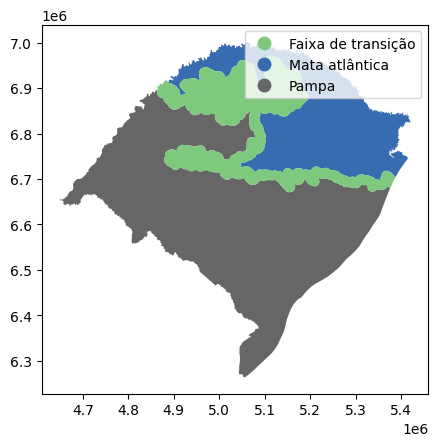

In [8]:
pampa.plot(column='bioma', cmap='Accent', legend=True)

In [ ]:
import geopandas as gpd

# Realizar o spatial join e adicionar apenas a coluna 'bioma'
df_0_10_pampa = gpd.sjoin(df_0_10, pampa[['bioma', 'geometry']], how='left', predicate='intersects')
df_0_10_pampa = df_0_10_pampa.drop(columns=['index_right'])
df_0_10_pampa.drop_duplicates(subset='pol_id', inplace=True)

In [12]:
df_0_10_pampa.columns

Index(['pol_id', 'nome_ti', 'etnia_nome', 'regeneration_%_se',
       'degeneration_%_se', 'forest_cover_2023_%_se', 'bioma_left',
       'forest_formation_se', 'grassland_se', 'soybean_se',
       'forest_plantation_se', 'urban_area_se', 'agropec_se',
       'regeneration_%_ex', 'degeneration_%_ex', 'forest_cover_2023_%_ex',
       'forest_formation_ex', 'grassland_ex', 'soybean_ex',
       'forest_plantation_ex', 'urban_area_ex', 'agropec_ex',
       'mining_threat_density_se', 'mining_threat_density_ex',
       'proximity_index', 'status_fundiario', 'txalfabeti_imputed',
       'road_density_se', 'road_density_ex', 'uhe_density_se',
       'uhe_density_ex', 'heat_density_se', 'heat_density_ex', 'ex_score',
       'se_score', 'ca_score', 'vulnerability_raw', 'vulnerability_index',
       'geometry', 'bioma_right'],
      dtype='object')

In [10]:
df_0_10_pampa.bioma.value_counts().to_csv('teste.csv')

AttributeError: 'GeoDataFrame' object has no attribute 'bioma'

In [26]:
from scipy.stats import ttest_ind

components = ['ca_score', 'ex_score', 'se_score', 'vulnerability_index']
results = {}

for comp in components:
    t_stat, p_value = ttest_ind(
        df_0_10[comp].dropna(),
        df_10_23[comp].dropna(),
        equal_var=False
    )
    results[comp] = {'t_statistic': t_stat, 'p_value': p_value}
    
print("Resultados do Teste t:")
for comp, res in results.items():
    print(f"{comp}: t = {res['t_statistic']:.3f}, p = {res['p_value']:.4f}")


Resultados do Teste t:
ca_score: t = 0.812, p = 0.4173
ex_score: t = 0.668, p = 0.5048
se_score: t = -1.337, p = 0.1823
vulnerability_index: t = -0.214, p = 0.8311


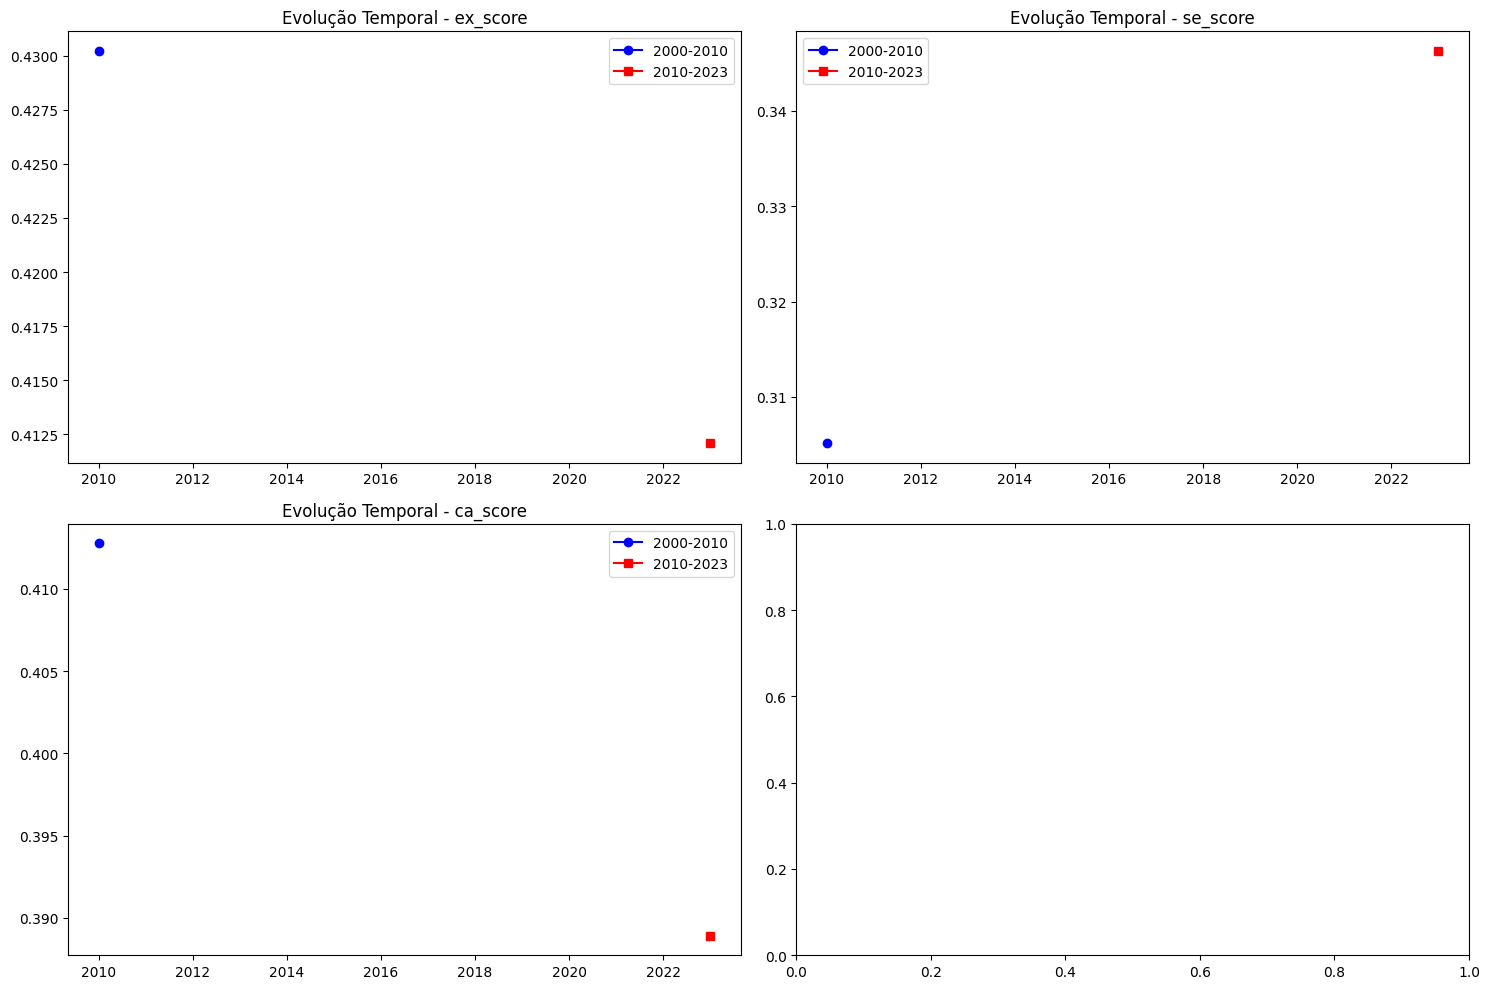

In [27]:
import matplotlib.pyplot as plt

# Criar gráficos de série temporal comparativa
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
components = ['ex_score', 'se_score', 'ca_score']
df_0_10['ano'] = 2010
df_10_23['ano'] = 2023

for i, comp in enumerate(components):
    ax = axes[i//2, i%2]
    
    # Médias anuais por período
    if 'ano' in df_0_10.columns:
        mean_2000 = df_0_10.groupby('ano')[comp].mean()
        mean_2010 = df_10_23.groupby('ano')[comp].mean()
        
        ax.plot(mean_2000.index, mean_2000.values, 'b-', label='2000-2010', marker='o')
        ax.plot(mean_2010.index, mean_2010.values, 'r-', label='2010-2023', marker='s')
        ax.set_title(f'Evolução Temporal - {comp}')
        ax.legend()
    
plt.tight_layout()
plt.show()

In [28]:
# Calcular mudanças percentuais médias
mean_2000 = df_0_10[components].mean()
mean_2010 = df_10_23[components].mean()

percent_change = ((mean_2010 - mean_2000) / mean_2000) * 100

print("Mudança Percentual Média:")
for comp in components:
    print(f"{comp}: {percent_change[comp]:.2f}%")

Mudança Percentual Média:
ex_score: -4.21%
se_score: 13.46%
ca_score: -5.77%


In [29]:
# Gerar relatório comparativo
print("RELATÓRIO COMPARATIVO - IVA 2000-2010 vs 2010-2023")
print("=" * 50)

for comp in components:
    print(f"\n{comp}:")
    print(f"  Média 1985-2000: {df_0_10[comp].mean():.3f}")
    print(f"  Média 2000-2023: {df_10_23[comp].mean():.3f}")
    print(f"  Diferença: {df_10_23[comp].mean() - df_0_10[comp].mean():.3f}")
    print(f"  Significância (p-value): {results[comp]['p_value']:.4f}")

RELATÓRIO COMPARATIVO - IVA 2000-2010 vs 2010-2023

ex_score:
  Média 1985-2000: 0.430
  Média 2000-2023: 0.412
  Diferença: -0.018
  Significância (p-value): 0.5048

se_score:
  Média 1985-2000: 0.305
  Média 2000-2023: 0.346
  Diferença: 0.041
  Significância (p-value): 0.1823

ca_score:
  Média 1985-2000: 0.413
  Média 2000-2023: 0.389
  Diferença: -0.024
  Significância (p-value): 0.4173


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams

# Configuração do estilo
plt.style.use('default')
rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("husl")

def plot_ethnicity_vulnerability_stats(gdf, vulnerability_columns=None):
    """
    Analisa e visualiza estatísticas de vulnerabilidade por etnia_nome_nome_nome
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame com colunas de vulnerabilidade e etnia
    vulnerability_columns : list, optional
        Lista de colunas de vulnerabilidade para analisar
        Se None, usa colunas padrão
    """
    
    if vulnerability_columns is None:
        vulnerability_columns = [
            'vulnerability_index', 
            'ex_score', 
            'se_score', 
            'ca_score'
        ]
    
    # Verificar se as colunas existem
    available_cols = [col for col in vulnerability_columns if col in gdf.columns]
    if not available_cols:
        raise ValueError("Nenhuma coluna de vulnerabilidade encontrada no GeoDataFrame")
    
    # Criar figura com subplots
    n_cols = len(available_cols)
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    # 1. Gráfico de barras com médias por etnia
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Calcular estatísticas por etnia
        stats_by_ethnicity = gdf.groupby('etnia_nome')[col].agg([
            'mean', 'std', 'count', 'min', 'max', 'median'
        ]).round(3)
        
        # Ordenar por média (maior para menor)
        stats_by_ethnicity = stats_by_ethnicity.sort_values('mean', ascending=False)
        
        # Plotar gráfico de barras
        bars = axes[i].bar(stats_by_ethnicity.index, stats_by_ethnicity['mean'],
                         yerr=stats_by_ethnicity['std'], 
                         capsize=5, alpha=0.8,
                         color=plt.cm.Set3(np.arange(len(stats_by_ethnicity))))
        
        axes[i].set_title(f'{col.upper()} - Média por Etnia\n(Ordenado por maior vulnerabilidade)')
        axes[i].set_ylabel('Valor Médio')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Adicionar valores nas barras
        for j, (idx, row) in enumerate(stats_by_ethnicity.iterrows()):
            axes[i].text(j, row['mean'] + row['std'] + 0.01, 
                       f'{row["mean"]:.3f}\n(n={row["count"]})', 
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 2. Boxplots detalhados por etnia
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Boxplot por etnia_nome
        boxplot_data = []
        ethnicities = []
        
        # Ordenar etnias pela mediana
        ethnicity_medians = gdf.groupby('etnia_nome')[col].median().sort_values(ascending=False)
        
        for ethnicity in ethnicity_medians.index:
            data = gdf[gdf['etnia_nome'] == ethnicity][col].dropna()
            if len(data) > 0:
                boxplot_data.append(data)
                ethnicities.append(ethnicity)
        
        box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
        
        # Colorir boxes
        colors = plt.cm.Set3(np.arange(len(ethnicities)))
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
        
        axes[i].set_title(f'{col.upper()} - Distribuição por Etnia\n(Ordenado por mediana)')
        axes[i].set_ylabel('Valor')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Adicionar informação de sample size
        for j, ethnicity in enumerate(ethnicities):
            n = len(gdf[gdf['etnia_nome'] == ethnicity])
            axes[i].text(j + 1, axes[i].get_ylim()[0] - 0.05, 
                       f'n={n}', ha='center', va='top', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 3. Heatmap de correlações entre componentes por etnia
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Heatmap 1: Médias por etnia
    ethnicity_means = gdf.groupby('etnia_nome')[available_cols].mean()
    sns.heatmap(ethnicity_means, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                center=ethnicity_means.values.mean(), ax=axes[0])
    axes[0].set_title('Médias de Vulnerabilidade por Etnia')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].tick_params(axis='y', rotation=0)
    
    # Heatmap 2: Contagem por etnia
    ethnicity_counts = gdf.groupby(['etnia_nome', 'bioma']).size().unstack(fill_value=0)
    sns.heatmap(ethnicity_counts, annot=True, fmt='.0f', cmap='Blues', ax=axes[1])
    axes[1].set_title('Número de Observações por Etnia')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Ranking detalhado
    print("=" * 80)
    print("RANKING DETALHADO POR ETNIA")
    print("=" * 80)
    
    for col in available_cols:
        print(f"\n{col.upper()} - Ranking por Etnia:")
        print("-" * 40)
        
        stats = gdf.groupby('etnia_nome')[col].agg(['mean', 'std', 'count', 'median']).round(4)
        stats = stats.sort_values('mean', ascending=False)
        
        for i, (ethnicity, row) in enumerate(stats.iterrows(), 1):
            rank = f"{i}º"
            print(f"{rank:4} {ethnicity:20}: {row['mean']:.4f} ± {row['std']:.4f} "
                  f"(mediana: {row['median']:.4f}, n={row['count']})")
    
    return stats

# Função adicional para análise comparativa
def plot_ethnicity_comparison(gdf, primary_ethnicity, compare_with=None, vulnerability_cols=['vulnerability_index', 'ex_score', 'se_score', 'ca_score']):
    """
    Compara uma etnia específica com outras
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame com os dados
    primary_ethnicity : str
        Etnia principal para comparação
    compare_with : list, optional
        Lista de etnias para comparar, se None compara com todas
    """
    
    if compare_with is None:
        compare_with = [eth for eth in gdf['etnia_nome'].unique() if eth != primary_ethnicity]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
        
    for i, col in enumerate(vulnerability_cols):
        if col not in gdf.columns or i >= len(axes):
            continue
        
        # Dados para comparação
        primary_data = gdf[gdf['etnia_nome'] == primary_ethnicity][col].dropna()
        comparison_data = []
        labels = [primary_ethnicity]
        
        for ethnicity in compare_with:
            data = gdf[gdf['etnia_nome'] == ethnicity][col].dropna()
            if len(data) > 0:
                comparison_data.append(data)
                labels.append(ethnicity)
        
        # Juntar todos os dados
        all_data = [primary_data] + comparison_data
        
        # Plot violin plot
        violin = axes[i].violinplot(all_data, showmeans=True, showmedians=True)
        
        # Colorir violinos
        colors = ['red'] + ['lightblue'] * len(comparison_data)
        for j, pc in enumerate(violin['bodies']):
            pc.set_facecolor(colors[j])
            pc.set_alpha(0.7)
        
        axes[i].set_title(f'{col.upper()} - {primary_ethnicity} vs Outras Etnias')
        axes[i].set_ylabel('Valor')
        axes[i].set_xticks(range(1, len(labels) + 1))
        axes[i].set_xticklabels(labels, rotation=45)
        
        # Adicionar informação estatística
        for j, data in enumerate(all_data, 1):
            axes[i].text(j, np.min(data) - 0.05, f'n={len(data)}', 
                       ha='center', va='top', fontsize=8)
    
    plt.tight_layout()
    plt.show()

In [25]:
gdf.etnia_nome.replace({'Guaraní': 'Guarani', "Guaraní,Kaingang": 'Guarani - Kaingang', 'Guarani Mbya': 'Guarani','0': 'Sem dados', None: 'Sem dados'}, inplace=True)

C:\Users\adminitsd\AppData\Local\Temp\ipykernel_5168\2826031290.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf.etnia_nome.replace({'Guaraní': 'Guarani', "Guaraní,Kaingang": 'Guarani - Kaingang', 'Guarani Mbya': 'Guarani','0': 'Sem dados', None: 'Sem dados'}, inplace=True)


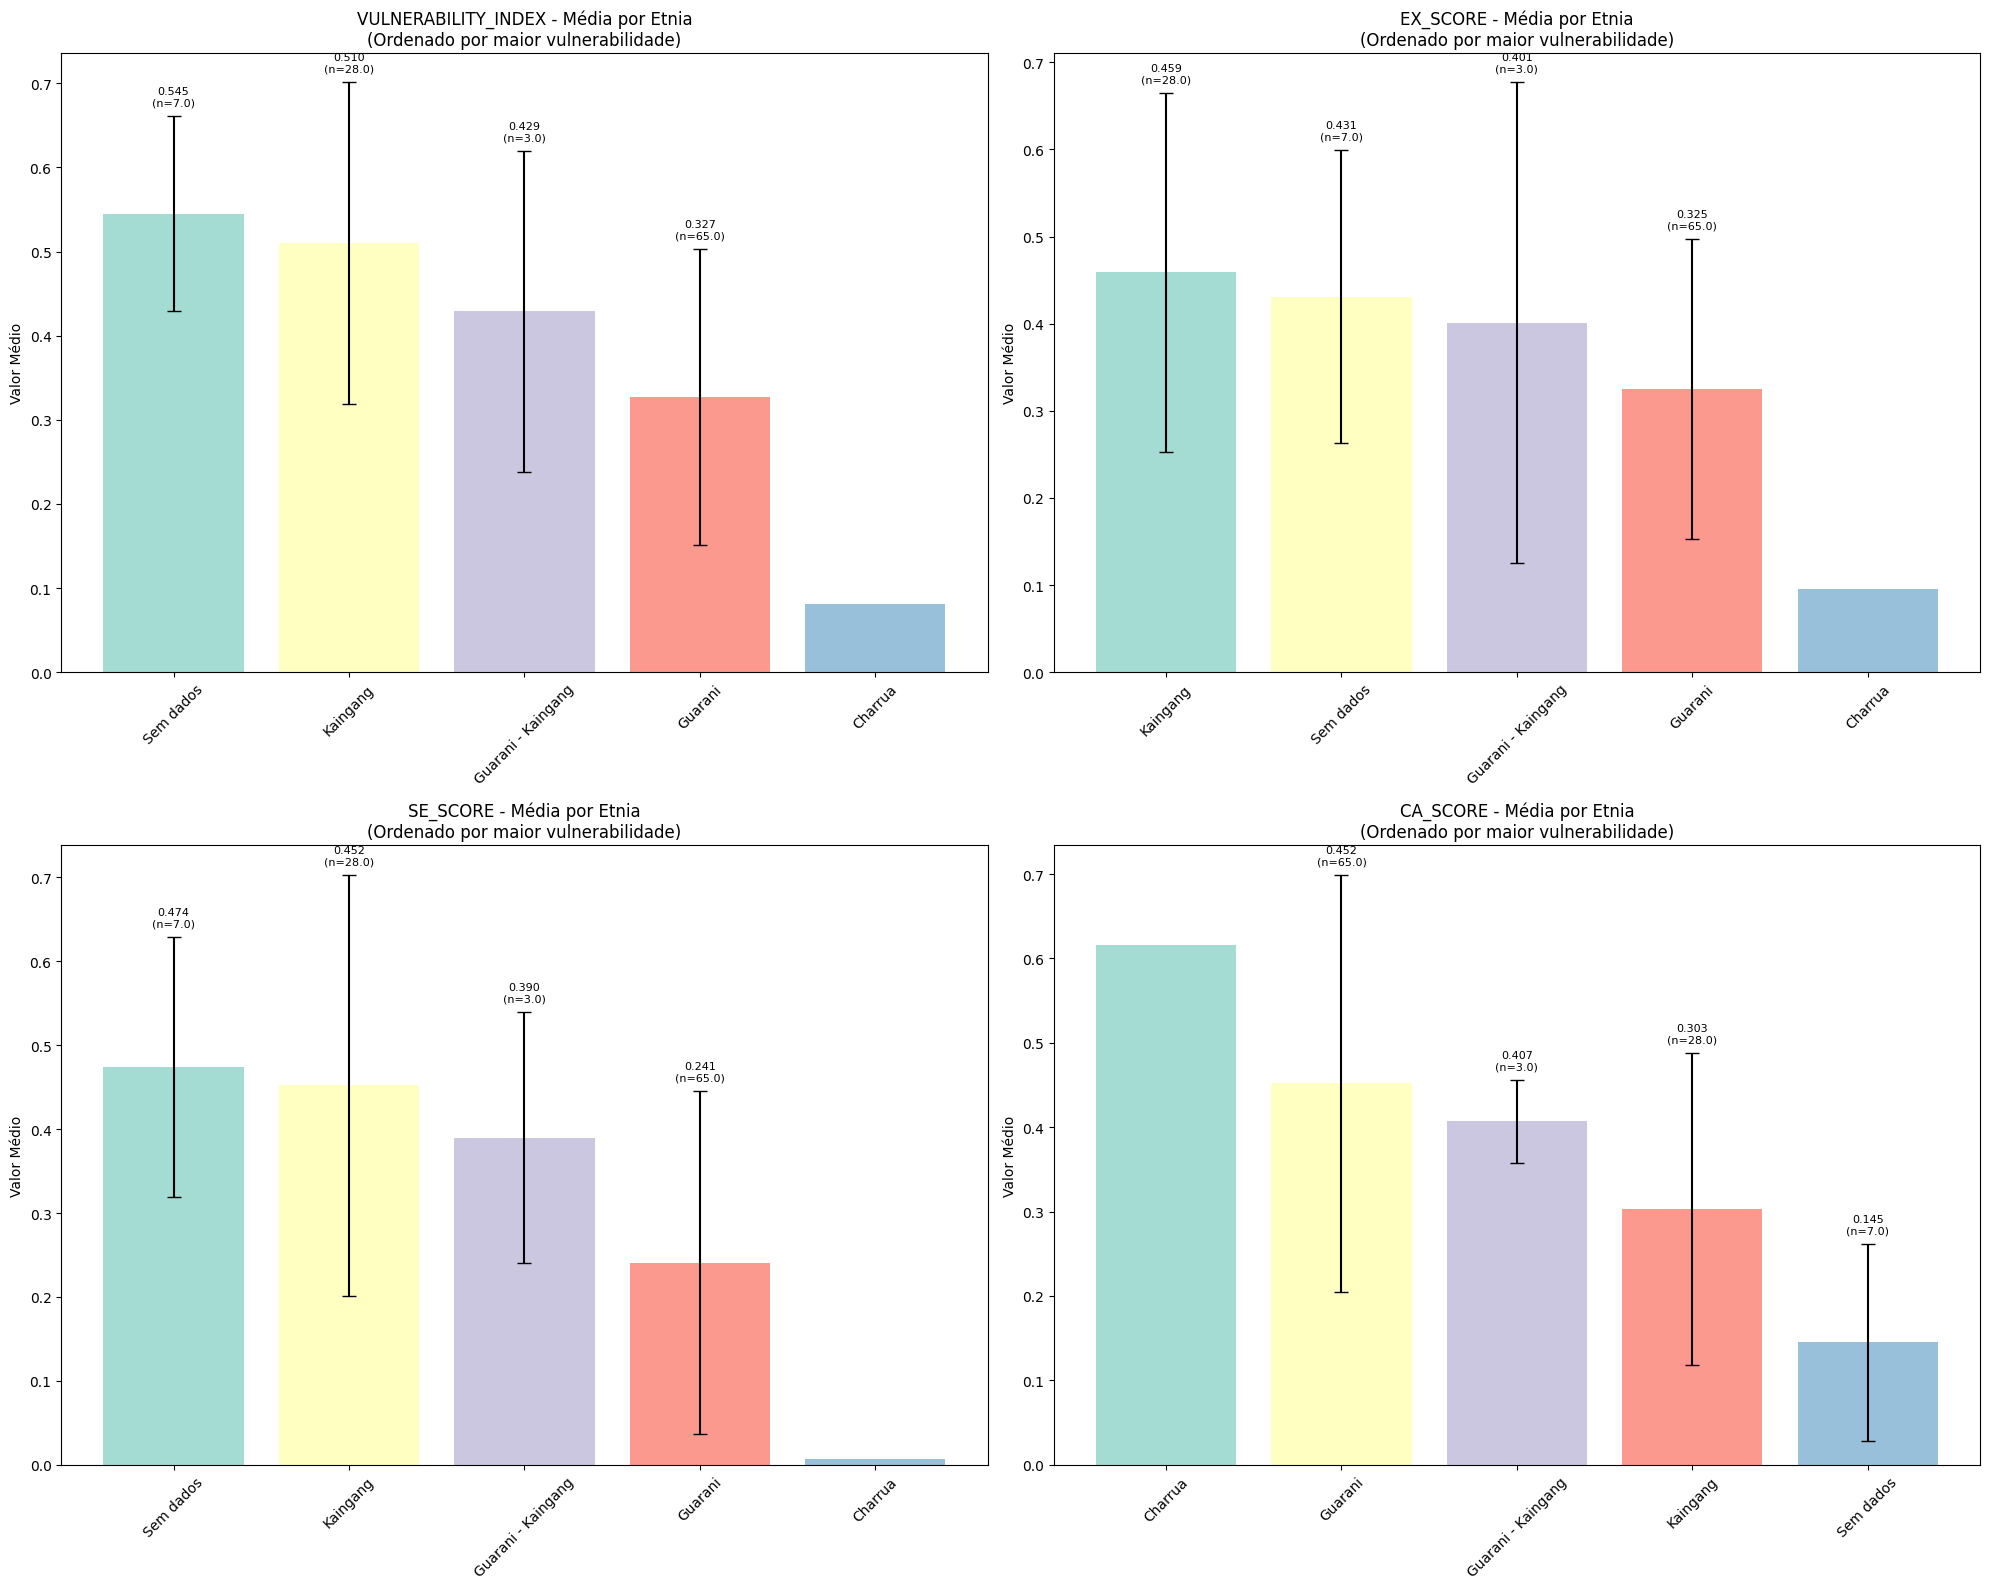

C:\Users\adminitsd\AppData\Local\Temp\ipykernel_5168\3596769333.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
C:\Users\adminitsd\AppData\Local\Temp\ipykernel_5168\3596769333.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
C:\Users\adminitsd\AppData\Local\Temp\ipykernel_5168\3596769333.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = axes[i].boxplot(boxplot_data, labels=ethnicities, patch_artist=True)
C:\Users\adminitsd\AppData\Local\Temp\ipykernel_5

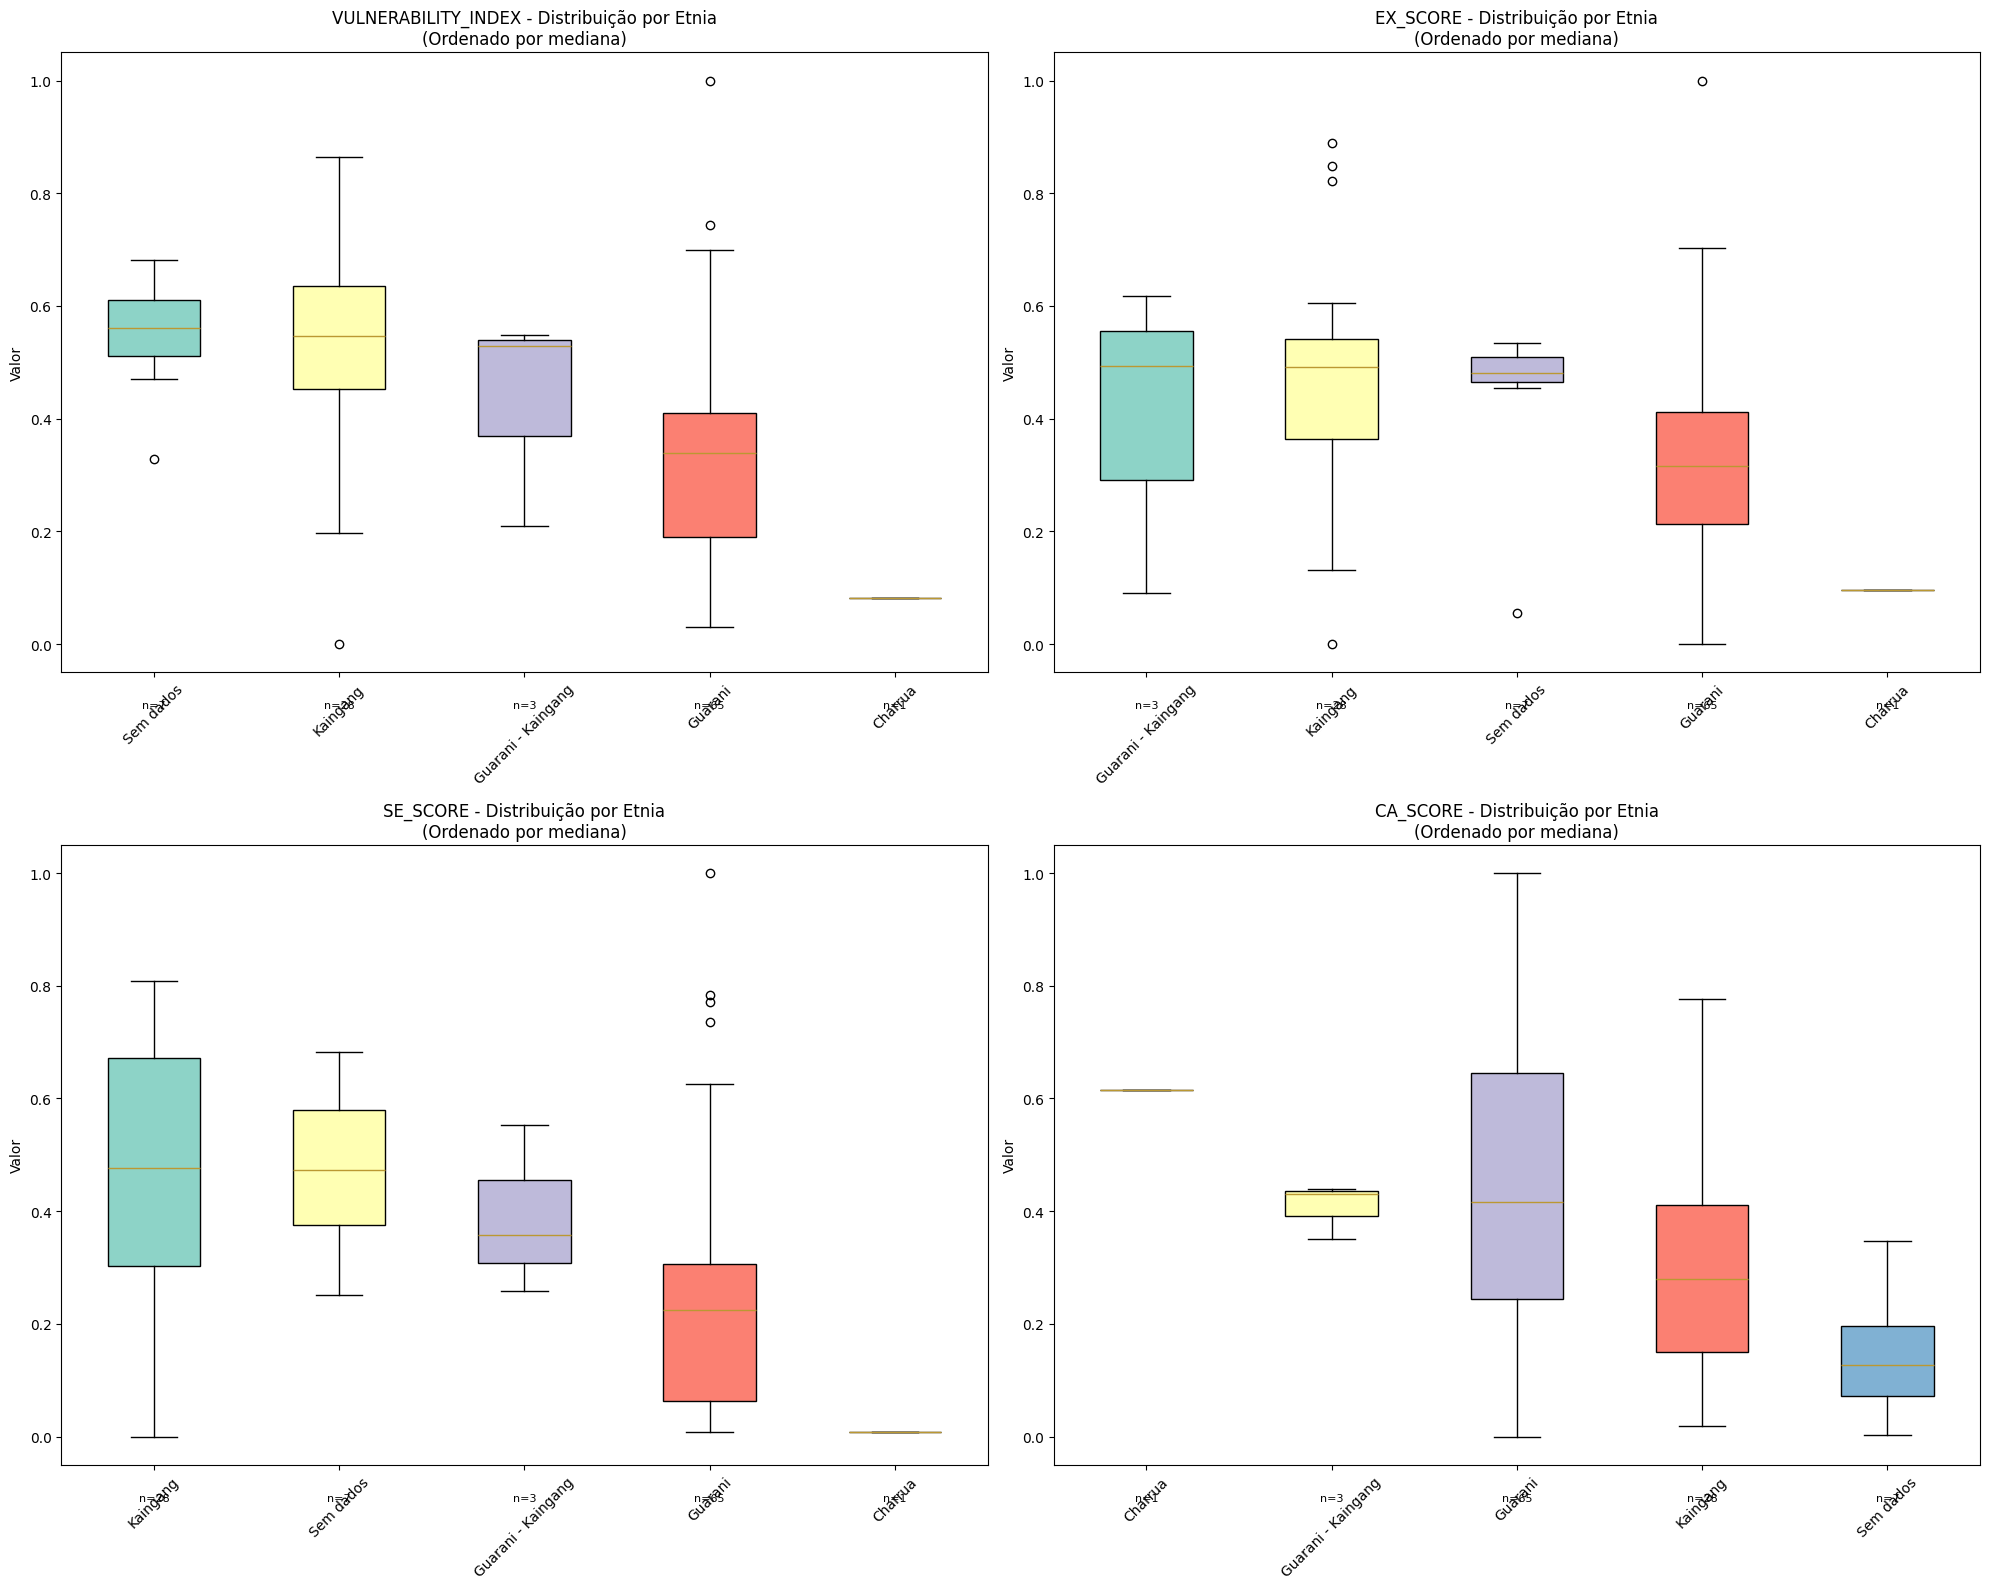

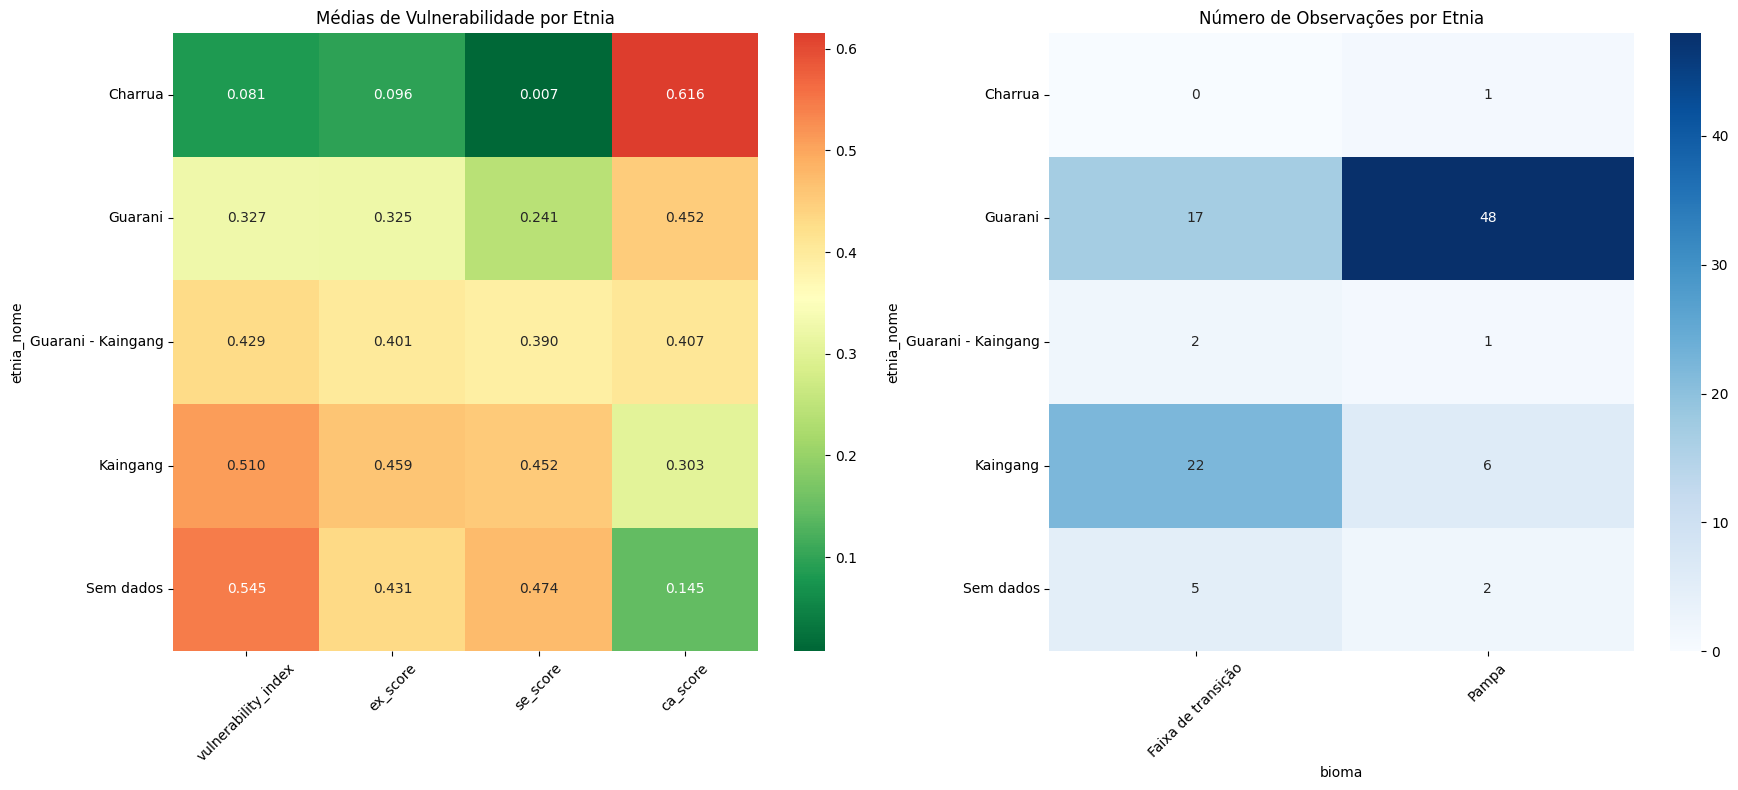

RANKING DETALHADO POR ETNIA

VULNERABILITY_INDEX - Ranking por Etnia:
----------------------------------------
1º   Sem dados           : 0.5450 ± 0.1160 (mediana: 0.5615, n=7.0)
2º   Kaingang            : 0.5095 ± 0.1908 (mediana: 0.5468, n=28.0)
3º   Guarani - Kaingang  : 0.4290 ± 0.1905 (mediana: 0.5289, n=3.0)
4º   Guarani             : 0.3266 ± 0.1761 (mediana: 0.3387, n=65.0)
5º   Charrua             : 0.0813 ± nan (mediana: 0.0813, n=1.0)

EX_SCORE - Ranking por Etnia:
----------------------------------------
1º   Kaingang            : 0.4590 ± 0.2061 (mediana: 0.4918, n=28.0)
2º   Sem dados           : 0.4313 ± 0.1684 (mediana: 0.4811, n=7.0)
3º   Guarani - Kaingang  : 0.4005 ± 0.2757 (mediana: 0.4937, n=3.0)
4º   Guarani             : 0.3248 ± 0.1718 (mediana: 0.3153, n=65.0)
5º   Charrua             : 0.0960 ± nan (mediana: 0.0960, n=1.0)

SE_SCORE - Ranking por Etnia:
----------------------------------------
1º   Sem dados           : 0.4741 ± 0.1546 (mediana: 0.4727, n=7.0)

In [32]:

stats = plot_ethnicity_vulnerability_stats(gdf[gdf['bioma'] != 'Mata atlântica'], ['vulnerability_index', 'ex_score', 'se_score', 'ca_score'])

In [17]:
stats

,mean,std,count,median
etnia_nome,,,,
Xokleng,0.7909,NaN,1,0.7909
Charrua,0.6155,NaN,1,0.6155
Guarani - Kaingang,0.4523,0.1092,4,0.4256
Guarani,0.4376,0.2485,39,0.3811
Sem dados,0.3937,0.2667,70,0.3946
Kaingang,0.3325,0.2037,26,0.2863


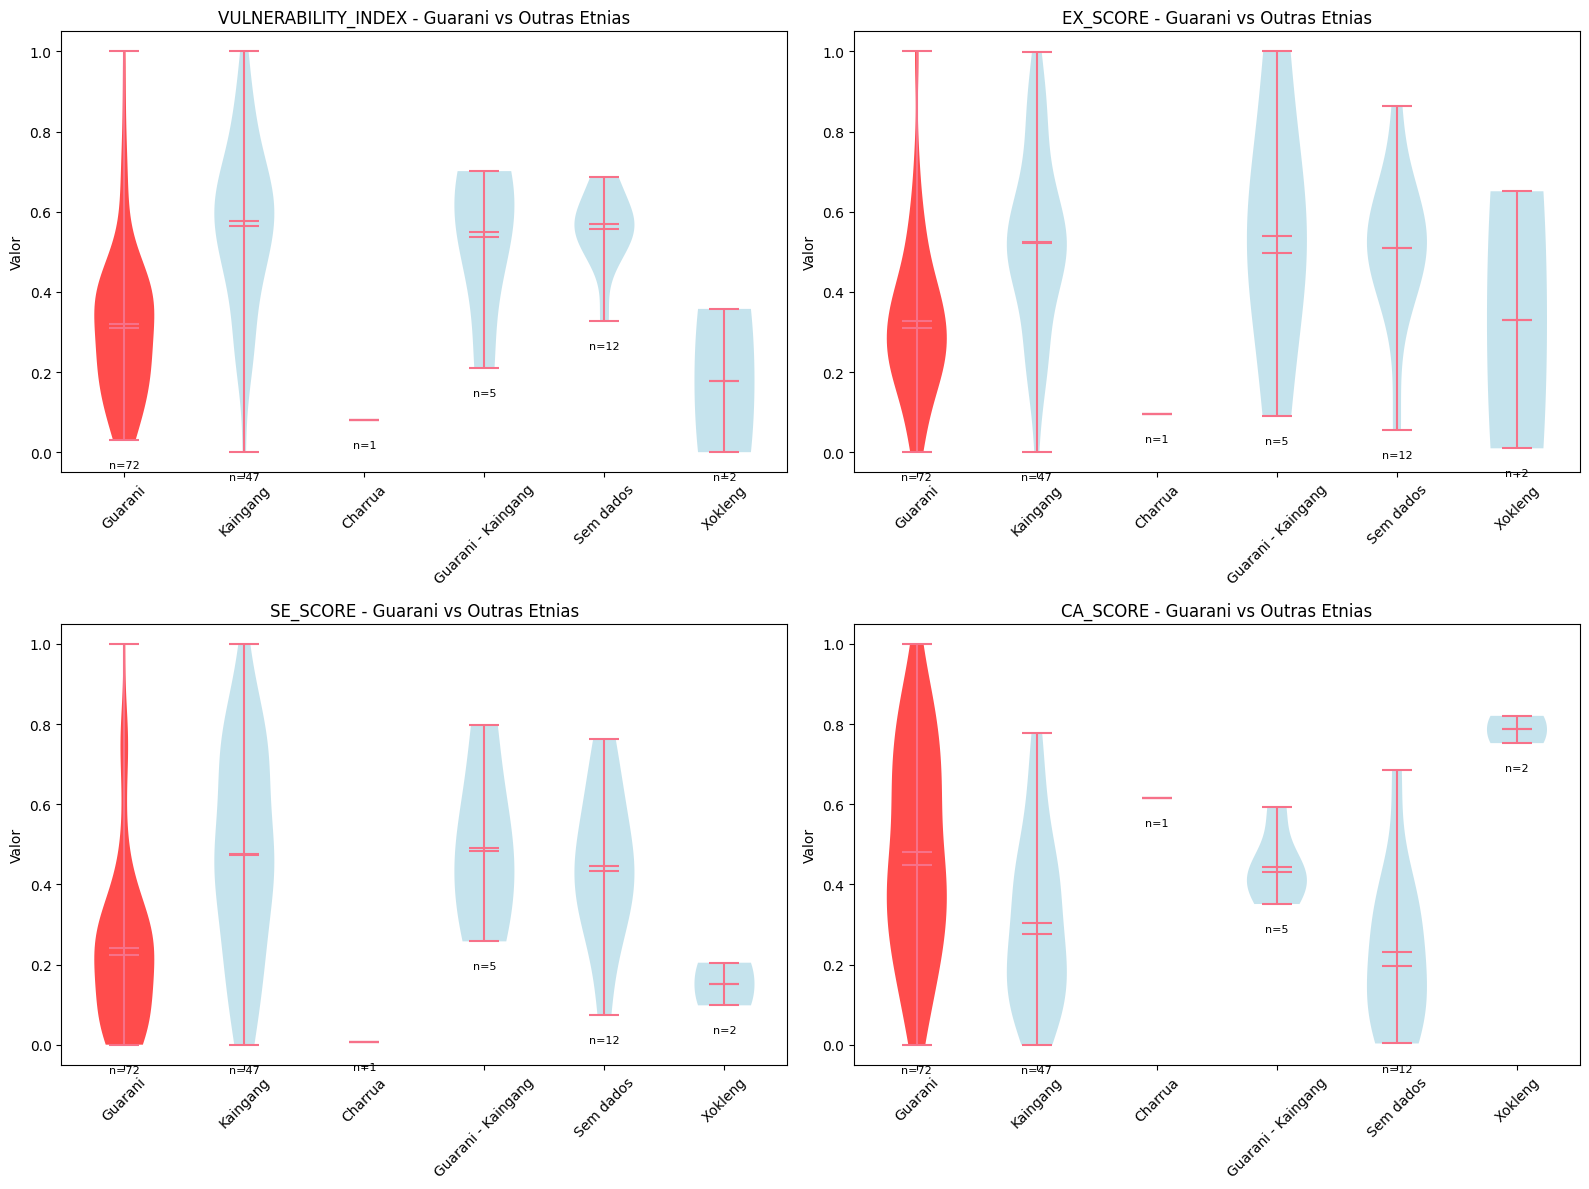

In [27]:
plot_ethnicity_comparison(gdf, 'Guarani')

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import rcParams
import itertools

# Configuração do estilo
plt.style.use('default')
rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette("husl")

def plot_biome_ethnicity_analysis(gdf, vulnerability_columns=None):
    """
    Analisa e visualiza diferenças entre biomas e etnias nos indicadores ambientais
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame com colunas: 'etnia_nome', 'bioma', e indicadores de vulnerabilidade
    vulnerability_columns : list, optional
        Lista de colunas de vulnerabilidade para analisar
    """
    
    if vulnerability_columns is None:
        vulnerability_columns = [
            'vulnerability_index', 
            'ex_score', 
            'se_score', 
            'ca_score'
        ]
    
    # Verificar se as colunas existem
    available_cols = [col for col in vulnerability_columns if col in gdf.columns]
    if not available_cols:
        raise ValueError("Nenhuma coluna de vulnerabilidade encontrada")
    
    # 1. ANÁLISE POR BIOMA
    print("=" * 80)
    print("ANÁLISE POR BIOMA")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Estatísticas por bioma
        stats_by_biome = gdf.groupby('bioma')[col].agg([
            'mean', 'std', 'count', 'median'
        ]).round(3).sort_values('mean', ascending=False)
        
        # Gráfico de barras
        bars = axes[i].bar(stats_by_biome.index, stats_by_biome['mean'],
                         yerr=stats_by_biome['std'], capsize=5, alpha=0.8,
                         color=plt.cm.Set3(np.arange(len(stats_by_biome))))
        
        axes[i].set_title(f'{col.upper()} - Por Bioma\n(Ordenado por maior valor)')
        axes[i].set_ylabel('Valor Médio')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Adicionar valores
        for j, (idx, row) in enumerate(stats_by_biome.iterrows()):
            axes[i].text(j, row['mean'] + row['std'] + 0.01, 
                       f'{row["mean"]:.3f}\nn={row["count"]}', 
                       ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # 2. HEATMAP BIOMA x ETNIA
    print("\n" + "=" * 80)
    print("HEATMAPS - INTERAÇÃO BIOMA x ETNIA")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Criar pivot table para heatmap
        pivot_data = gdf.pivot_table(
            values=col, 
            index='etnia_nome', 
            columns='bioma', 
            aggfunc='mean'
        ).round(3)
        
        # Heatmap
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlGn_r', 
                   center=pivot_data.values.mean(), ax=axes[i],
                   cbar_kws={'label': f'Média {col}'})
        
        axes[i].set_title(f'Heatmap: {col.upper()} - Etnia x Bioma')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].tick_params(axis='y', rotation=0)
    
    plt.tight_layout()
    plt.show()
    
    # 3. GRÁFICO DE CAIXAS COMBINADO (BIOMA x ETNIA)
    print("\n" + "=" * 80)
    print("DISTRIBUIÇÃO CONJUNTA - BIOMA x ETNIA")
    print("=" * 80)
    
    # Selecionar combinações mais relevantes
    biome_ethnicity_counts = gdf.groupby(['bioma', 'etnia_nome']).size().reset_index(name='count')
    significant_combinations = biome_ethnicity_counts[biome_ethnicity_counts['count'] >= 3]
    
    if len(significant_combinations) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(20, 16))
        axes = axes.flatten()
        
        for i, col in enumerate(available_cols):
            if i >= len(axes):
                break
                
            # Filtrar dados para combinações significativas
            plot_data = gdf.merge(significant_combinations[['bioma', 'etnia_nome']], 
                                on=['bioma', 'etnia_nome'])
            
            # Criar labels combinadas
            plot_data['bioma_etnia'] = plot_data['bioma'] + ' - ' + plot_data['etnia_nome']
            
            # Ordenar por valor médio
            order = plot_data.groupby('bioma_etnia')[col].mean().sort_values(ascending=False).index
            
            # Boxplot
            sns.boxplot(data=plot_data, x='bioma_etnia', y=col, ax=axes[i], order=order)
            axes[i].set_title(f'{col.upper()} - Distribuição por Bioma e Etnia\n(n≥3 por combinação)')
            axes[i].set_ylabel('Valor')
            axes[i].tick_params(axis='x', rotation=45)
            
            # Adicionar contagem
            for j, combo in enumerate(order):
                n = len(plot_data[plot_data['bioma_etnia'] == combo])
                axes[i].text(j, axes[i].get_ylim()[0] - 0.05, f'n={n}', 
                           ha='center', va='top', fontsize=8)
        
        plt.tight_layout()
        plt.show()
    
    # 4. ANÁLISE DE VARIAÇÃO ENTRE GRUPOS
    print("\n" + "=" * 80)
    print("ANÁLISE DE VARIAÇÃO - BIOMA vs ETNIA")
    print("=" * 80)
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for i, col in enumerate(available_cols):
        if i >= len(axes):
            break
            
        # Calcular variância entre grupos
        variance_biome = gdf.groupby('bioma')[col].var().mean()
        variance_ethnicity = gdf.groupby('etnia_nome')[col].var().mean()
        total_variance = gdf[col].var()
        
        # Gráfico de variância
        labels = ['Entre Biomas', 'Entre Etnias', 'Variância Total']
        values = [variance_biome, variance_ethnicity, total_variance]
        
        bars = axes[i].bar(labels, values, alpha=0.8, 
                         color=['skyblue', 'lightcoral', 'lightgreen'])
        
        axes[i].set_title(f'Variância de {col.upper()} entre Grupos')
        axes[i].set_ylabel('Variância')
        
        # Adicionar valores
        for j, v in enumerate(values):
            axes[i].text(j, v + 0.001, f'{v:.4f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # 5. ANÁLISE ESTATÍSTICA DETALHADA
    print("\n" + "=" * 80)
    print("ESTATÍSTICAS DETALHADAS POR BIOMA E ETNIA")
    print("=" * 80)
    
    for col in available_cols:
        print(f"\n{col.upper()} - Estatísticas por Bioma:")
        print("-" * 50)
        
        biome_stats = gdf.groupby('bioma')[col].agg(['mean', 'std', 'count', 'min', 'max']).round(4)
        biome_stats = biome_stats.sort_values('mean', ascending=False)
        print(biome_stats)
        
        print(f"\n{col.upper()} - Estatísticas por Etnia:")
        print("-" * 50)
        
        ethnicity_stats = gdf.groupby('etnia_nome')[col].agg(['mean', 'std', 'count', 'min', 'max']).round(4)
        ethnicity_stats = ethnicity_stats.sort_values('mean', ascending=False)
        print(ethnicity_stats)
        
        # Estatísticas combinadas
        print(f"\n{col.upper()} - Combinações Bioma-Etnia (n≥3):")
        print("-" * 50)
        
        combo_stats = gdf.groupby(['bioma', 'etnia_nome'])[col].agg(['mean', 'std', 'count']).round(4)
        combo_stats = combo_stats[combo_stats['count'] >= 3].sort_values('mean', ascending=False)
        
        if len(combo_stats) > 0:
            print(combo_stats)
        else:
            print("Nenhuma combinação com n≥3")
    
    return gdf

# Função adicional para análise específica de combinações
def plot_biome_ethnicity_interaction(gdf, target_biomas=None, target_etnias=None, vulnerability_cols = ['vulnerability_index', 'ex_score', 'se_score', 'ca_score']):
    """
    Análise detalhada de interações específicas entre biomas e etnias
    """
    
    if target_biomas is None:
        target_biomas = gdf['bioma'].unique()
    if target_etnias is None:
        target_etnias = gdf['etnia_nome'].unique()
    
    # Filtrar dados
    filtered_data = gdf[gdf['bioma'].isin(target_biomas) & gdf['etnia_nome'].isin(target_etnias)]
    
    # Criar grid de plots
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    
    
    for i, col in enumerate(vulnerability_cols):
        if col not in gdf.columns or i >= len(axes):
            continue
        
        # Pointplot com interação
        sns.pointplot(data=filtered_data, x='bioma', y=col, hue='etnia_nome',
                     ax=axes[i], dodge=True, markers=['o', 's', 'D', '^', 'v'],
                     linestyles=['-', '--', '-.', ':'])
        
        axes[i].set_title(f'{col.upper()} - Interação Bioma x Etnia')
        axes[i].set_ylabel('Valor Médio')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(title='Etnia', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        # Adicionar informação de sample size
        combo_counts = filtered_data.groupby(['bioma', 'etnia_nome']).size()
        for j, biome in enumerate(filtered_data['bioma'].unique()):
            for k, ethnicity in enumerate(filtered_data['etnia_nome'].unique()):
                if (biome, ethnicity) in combo_counts.index:
                    n = combo_counts[(biome, ethnicity)]
                    if n > 0:
                        axes[i].text(j + k*0.1 - 0.2, filtered_data[col].min() - 0.1, 
                                   f'n={n}', fontsize=6, alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [9]:
gdf = gpkg.read_layer('vindex_1985_2023_car_v1')

ANÁLISE POR BIOMA


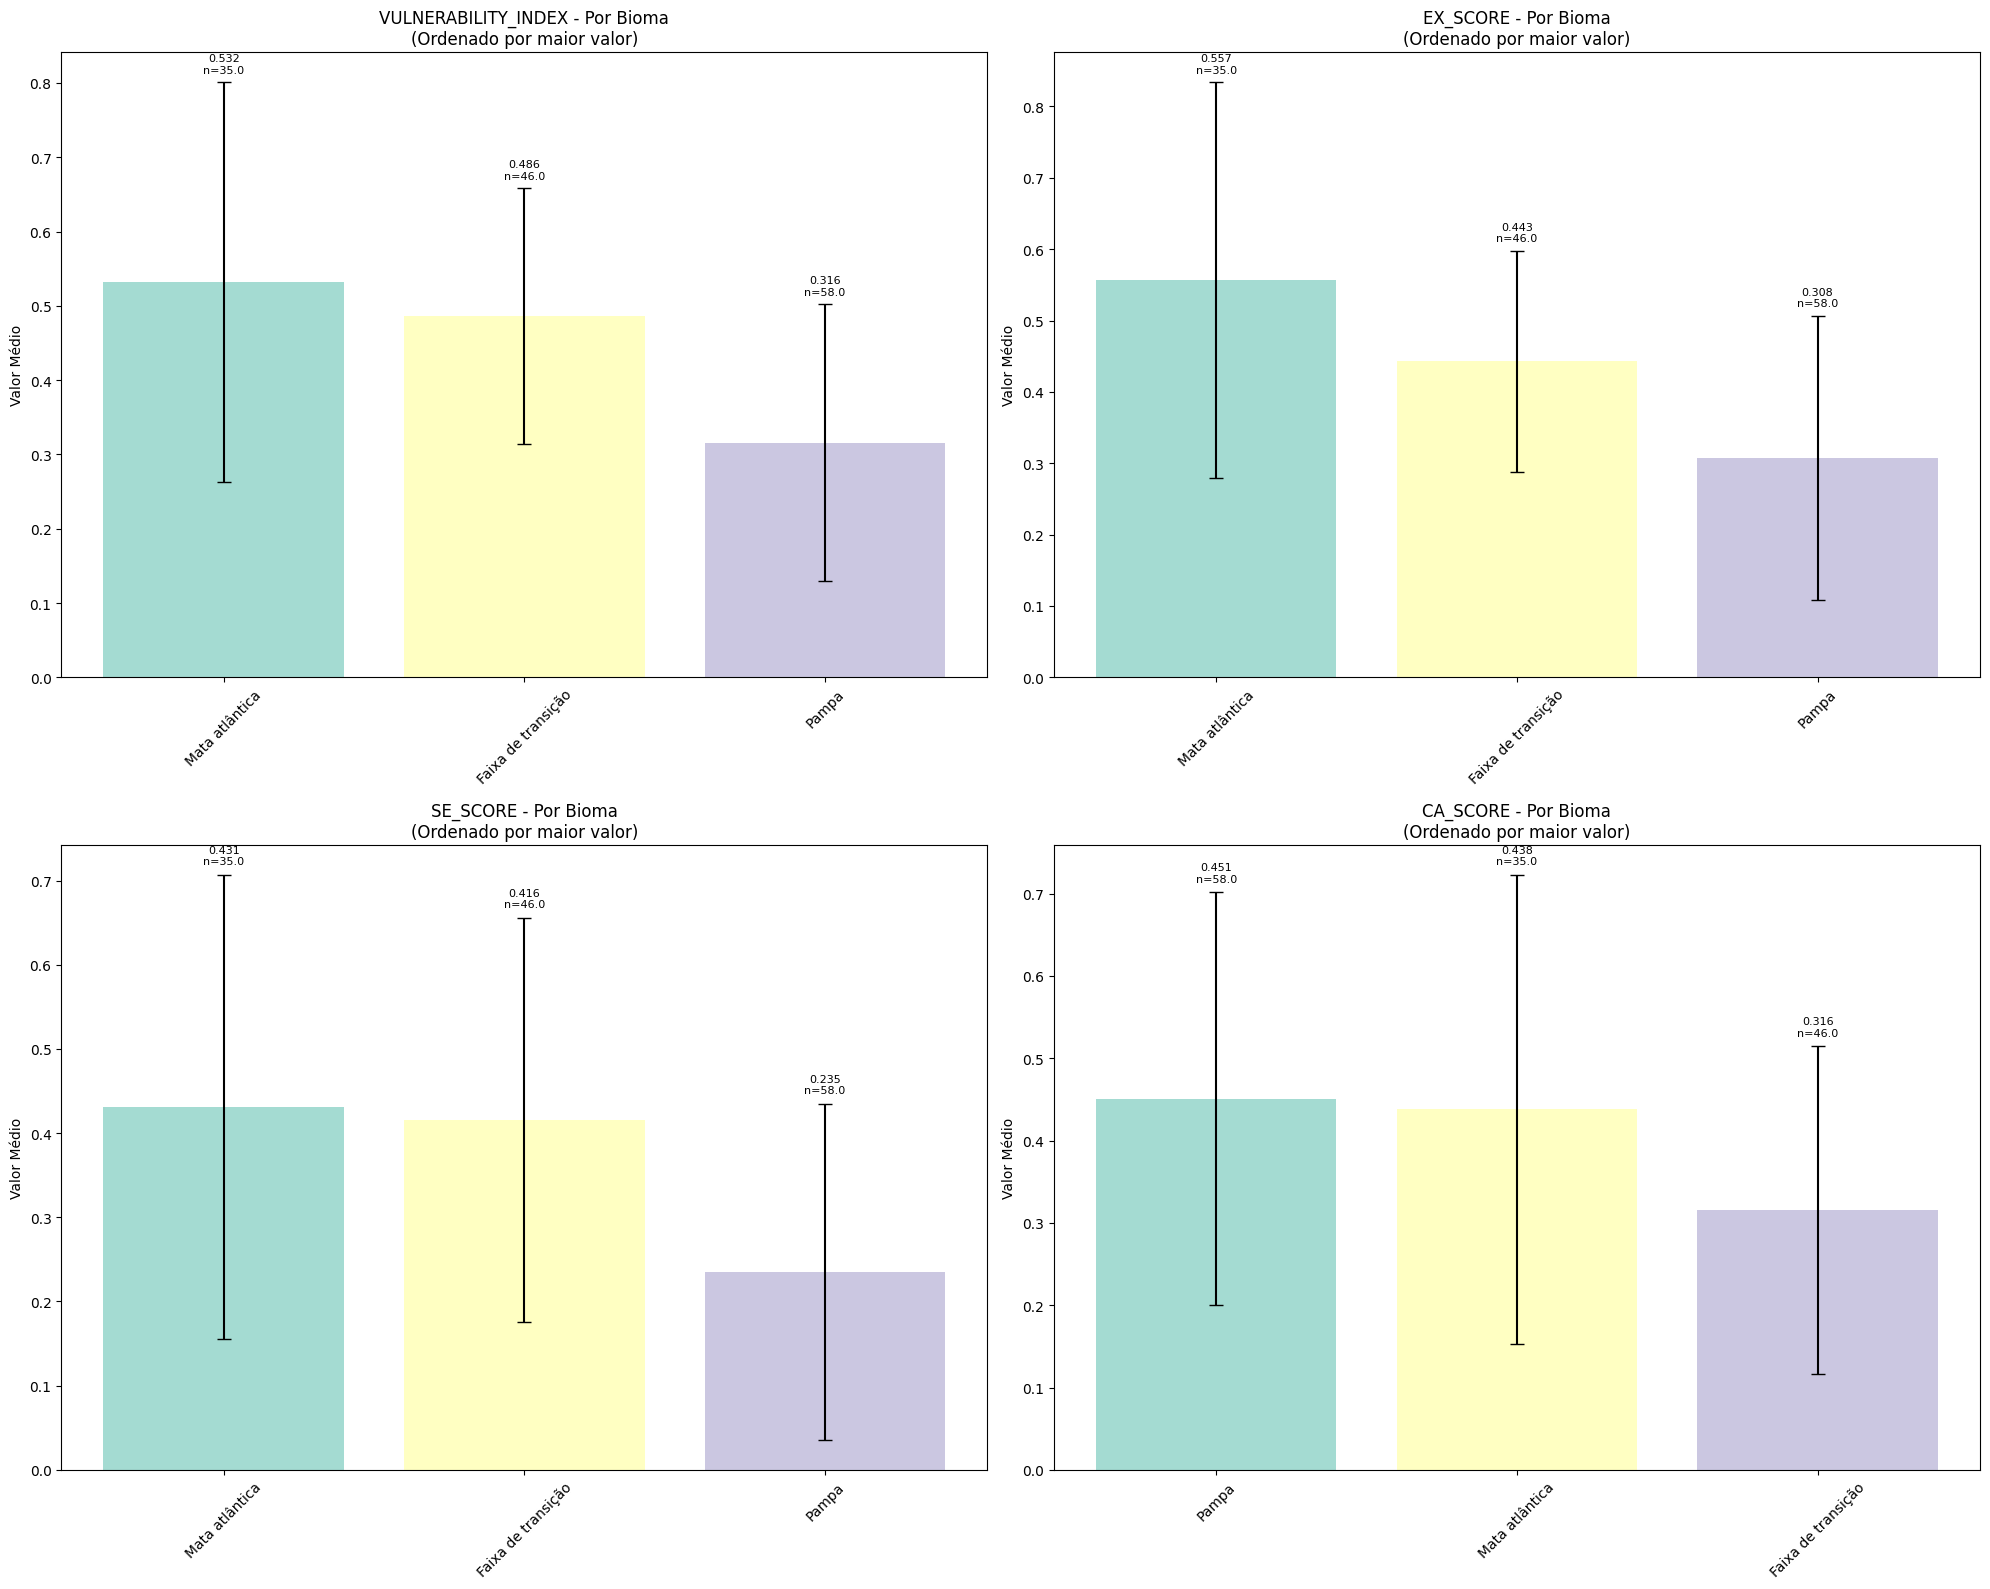


HEATMAPS - INTERAÇÃO BIOMA x ETNIA


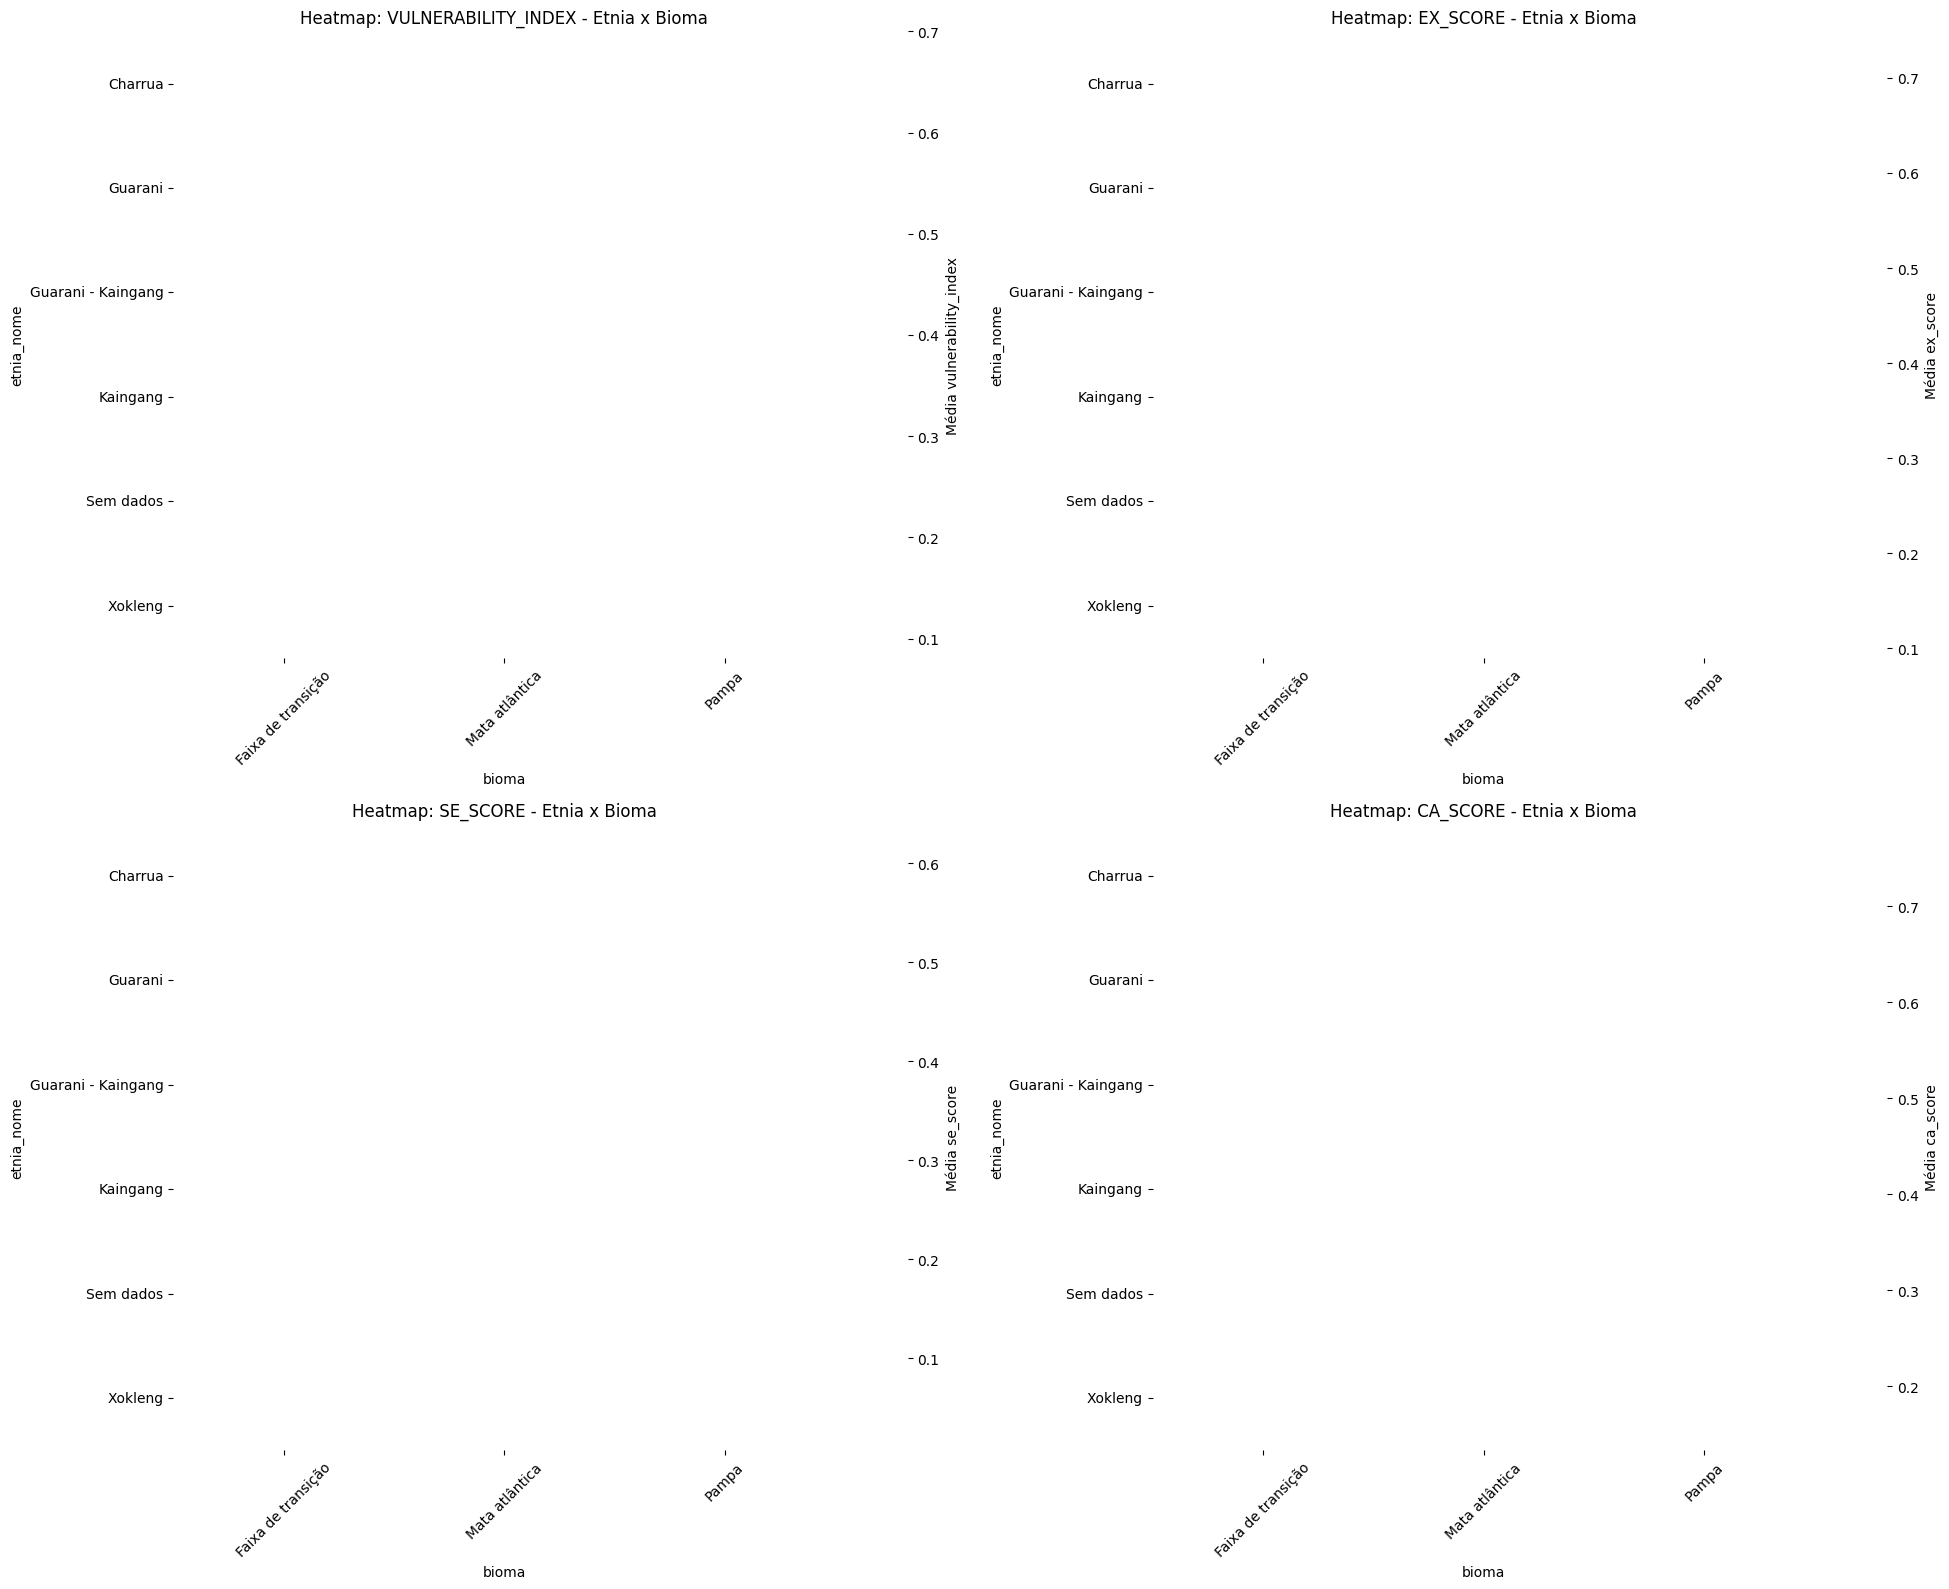


DISTRIBUIÇÃO CONJUNTA - BIOMA x ETNIA


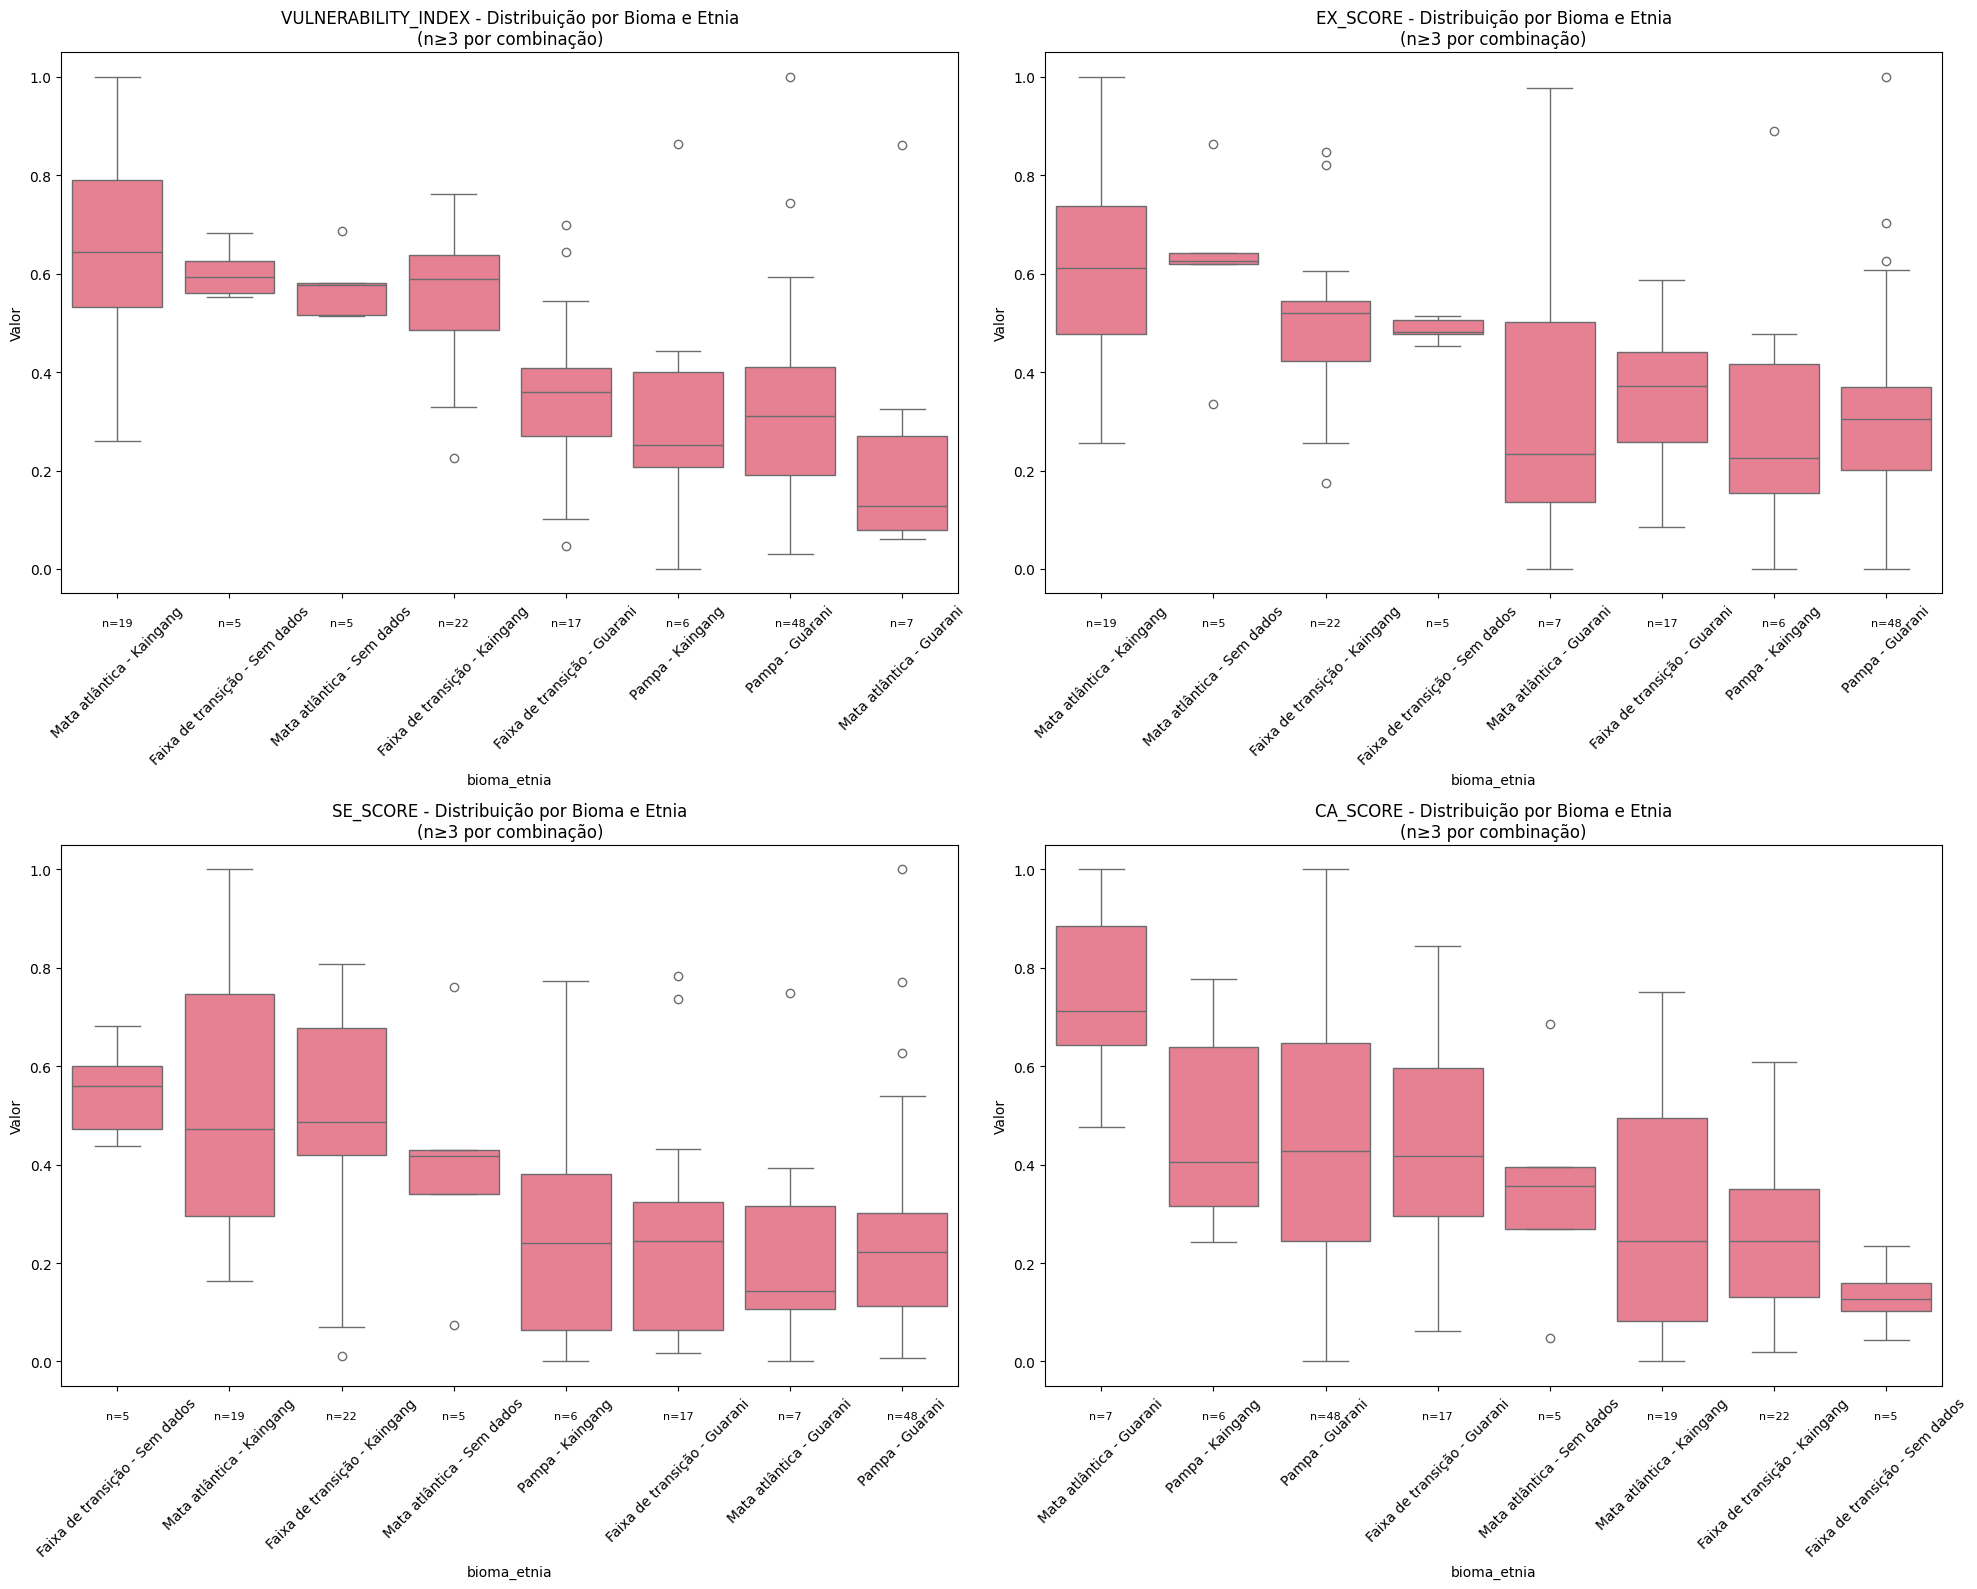


ANÁLISE DE VARIAÇÃO - BIOMA vs ETNIA


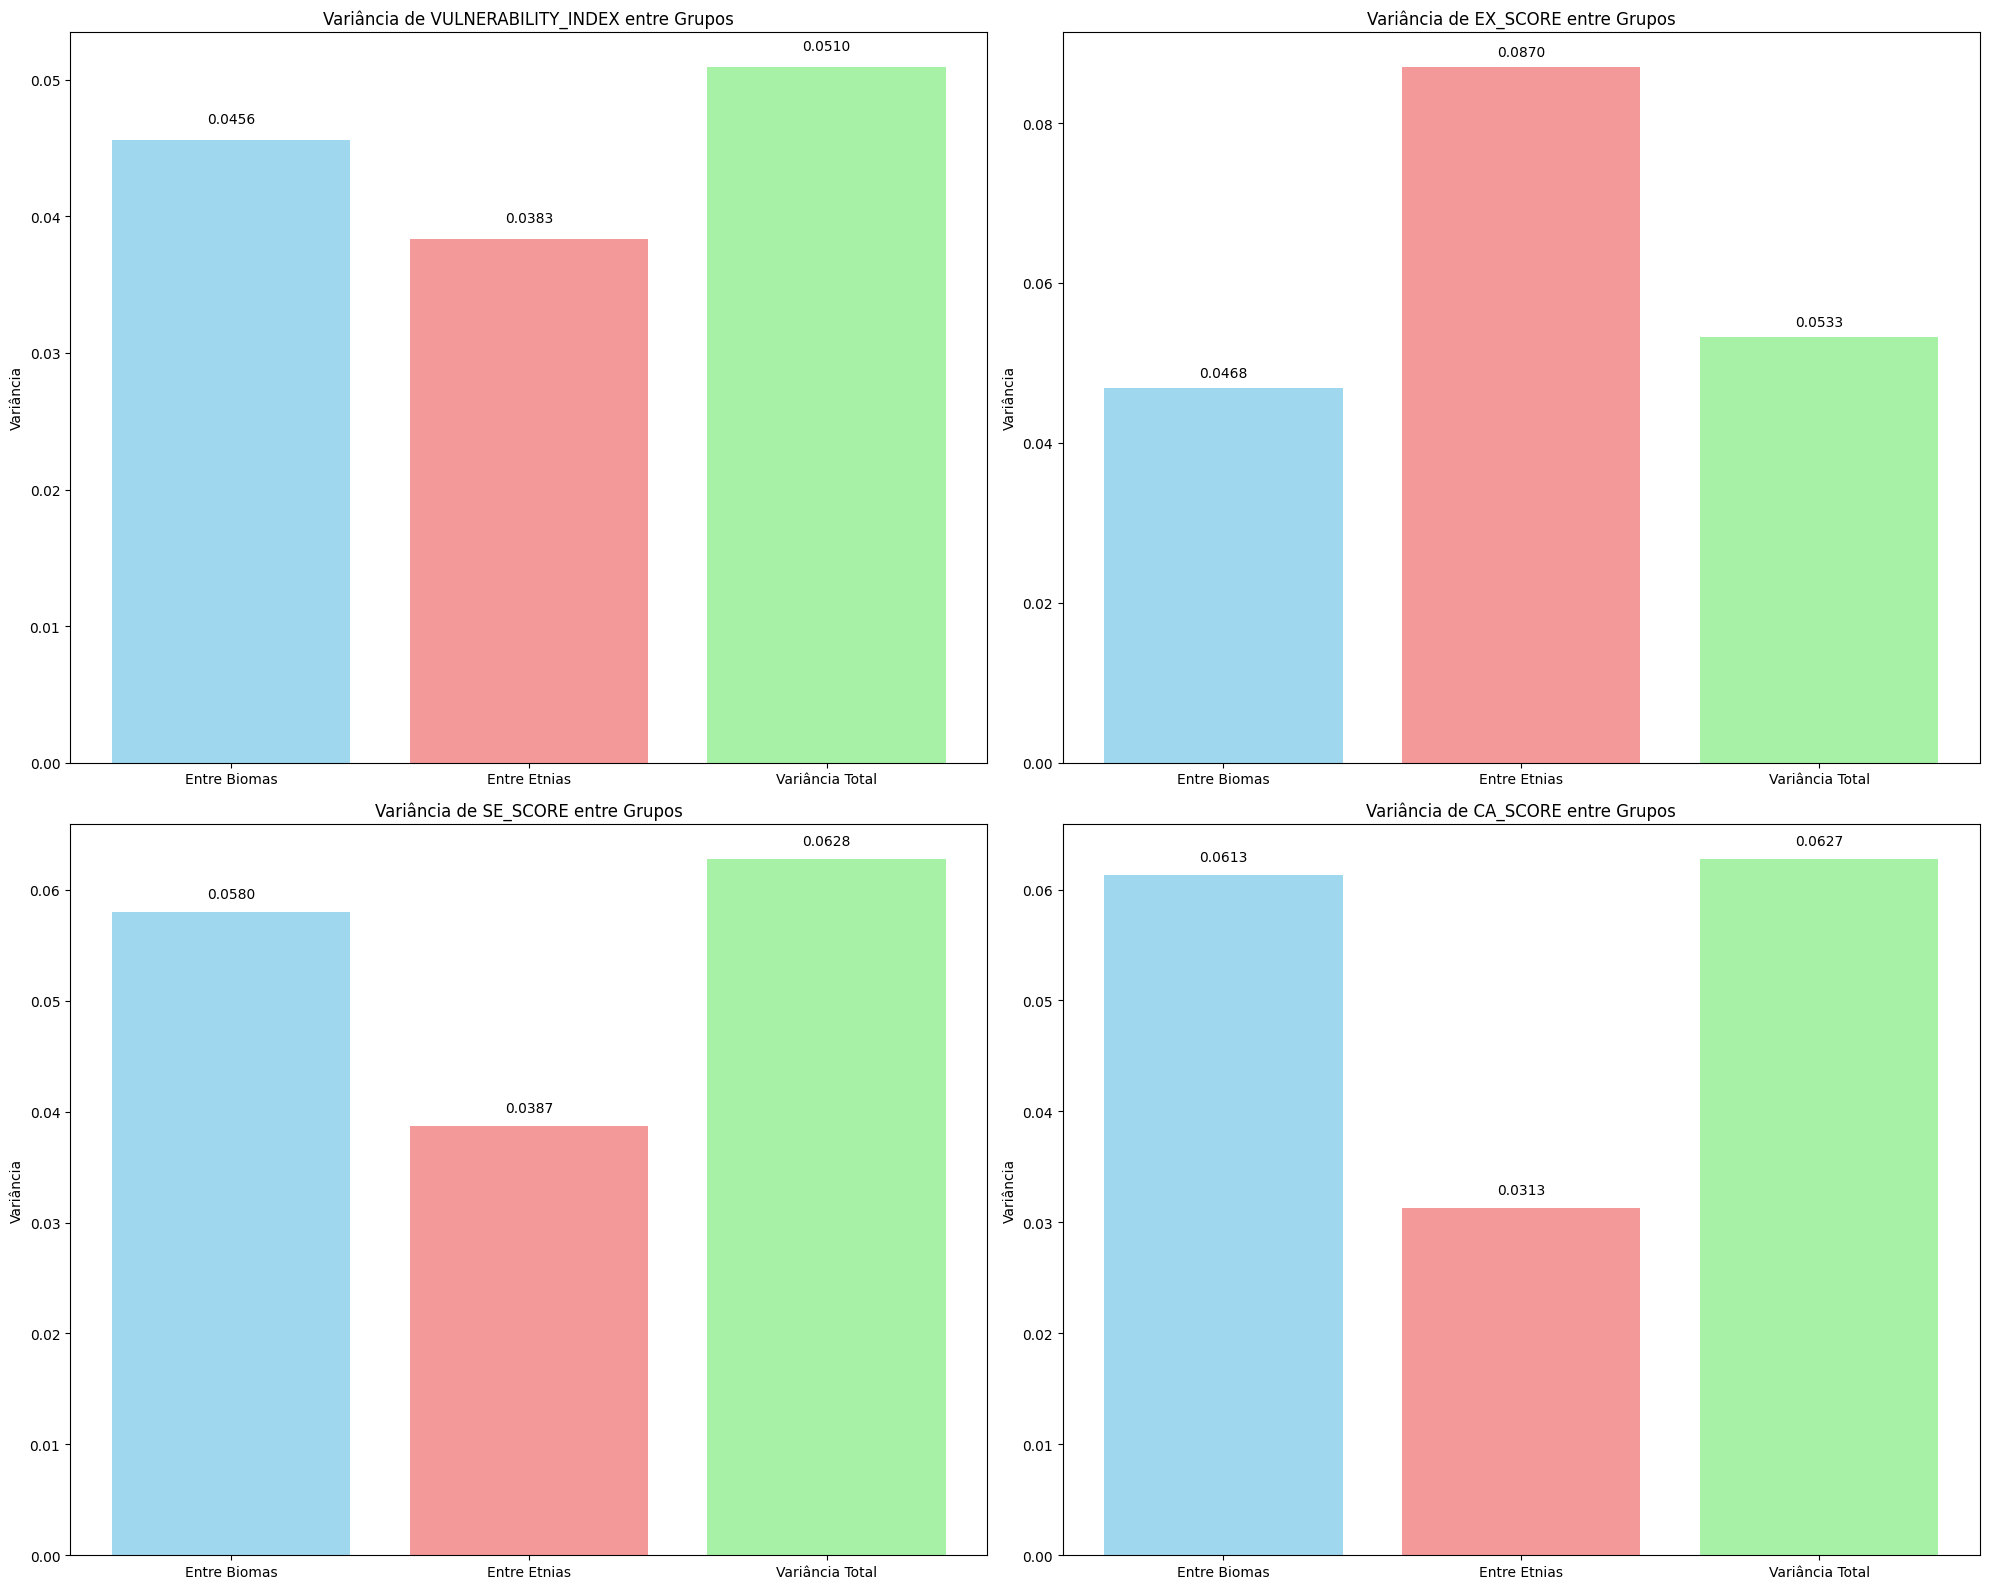


ESTATÍSTICAS DETALHADAS POR BIOMA E ETNIA

VULNERABILITY_INDEX - Estatísticas por Bioma:
--------------------------------------------------
                      mean     std  count     min     max
bioma                                                    
Mata atlântica      0.5319  0.2692     35  0.0000  1.0000
Faixa de transição  0.4855  0.1722     46  0.0472  0.7627
Pampa               0.3163  0.1864     58  0.0000  1.0000

VULNERABILITY_INDEX - Estatísticas por Etnia:
--------------------------------------------------
                      mean     std  count     min     max
etnia_nome                                               
Kaingang            0.5639  0.2067     47  0.0000  1.0000
Sem dados           0.5575  0.0970     12  0.3277  0.6877
Guarani - Kaingang  0.5376  0.2006      5  0.2093  0.7013
Guarani             0.3191  0.1881     72  0.0310  1.0000
Xokleng             0.1787  0.2528      2  0.0000  0.3575
Charrua             0.0813     NaN      1  0.0813  0.0813

VULNER

,pol_id,nome_ti,etnia_nome,regeneration_%_se,degeneration_%_se,forest_cover_2023_%_se,bioma,forest_formation_se,grassland_se,soybean_se,...,ex_score,se_score,ca_score,vulnerability_raw,vulnerability_index,vulnerability_category,ca_category_norm,se_category_norm,ex_category_norm,geometry
0,0,Maquiné,Guarani,65.798611,0.087977,44.041071,Faixa de transição,88.578745,0.000000,0.000000,...,0.257182,0.059544,0.659546,0.330886,0.173388,Muito baixo,Muito Alta,Muito baixo,Baixo,MULTIPOLYGON Z (((5366397.945 6711242.732 -9.4...
1,1,Arakuã - Ka'aguy Mirim,Guarani,58.593750,0.016561,48.376481,Pampa,54.459335,38.770795,0.002557,...,0.166925,0.022410,0.755521,0.243280,0.086327,Muito baixo,Excepcional,Muito baixo,Muito baixo,MULTIPOLYGON Z (((5287377.789 6653737.619 -9.4...
2,2,Gãh Ré,Kaingang,24.242424,0.007519,67.241379,Pampa,43.548387,23.118280,0.000000,...,0.132136,0.027959,0.286736,0.354776,0.197131,Baixo,Média,Muito baixo,Muito baixo,MULTIPOLYGON Z (((5276505.692 6670909.123 -9.4...
3,3,0,Guarani,24.855491,0.187500,14.124668,Pampa,0.000000,4.371217,0.000000,...,0.353976,0.314801,0.113019,0.618445,0.459161,Alto,Muito baixa,Alto,Médio,MULTIPOLYGON Z (((5259479.817 6647130.844 -9.4...
4,4,Aldeia Guyra Nhendu,Guarani,0.000000,0.174178,37.624861,Faixa de transição,84.016393,0.000000,0.000000,...,0.085544,0.071527,0.440262,0.302029,0.144711,Muito baixo,Alta,Baixo,Muito baixo,MULTIPOLYGON Z (((5372998.368 6713607.226 -9.4...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,132,Aldeia Jamã Ty Jahn (Coqueiro),Kaingang,10.400000,0.000000,18.421053,Mata atlântica,46.405229,0.000000,0.000000,...,0.999175,0.299926,0.244780,0.753114,0.726688,Crítico,Baixa,Médio,Crítico,MULTIPOLYGON Z (((5204224.535 6727070.187 -9.4...
135,134,Campestre Baixo,Sem dados,8.695652,0.695165,18.693694,Mata atlântica,33.498759,0.000000,0.000000,...,0.625161,0.430558,0.394203,0.653967,0.576546,Muito Alto,Alta,Muito Alto,Crítico,MULTIPOLYGON Z (((5237923.486 6735323.035 -9.4...
136,135,Linha Riachuelo,Sem dados,9.713024,0.160418,38.143004,Mata atlântica,57.136895,0.000000,0.040307,...,0.335327,0.762116,0.685497,0.613442,0.515178,Alto,Excepcional,Crítico,Médio,MULTIPOLYGON Z (((5277007.845 6797554.234 -9.4...
137,136,Frutibel,Sem dados,0.000000,0.530383,30.623819,Mata atlântica,0.000000,49.734982,0.006273,...,0.863955,0.416680,0.355752,0.727355,0.687680,Crítico,Média,Alto,Crítico,MULTIPOLYGON Z (((5375162.885 6819026.145 -9.4...


In [30]:
plot_biome_ethnicity_analysis(gdf, ['vulnerability_index', 'ex_score', 'se_score', 'ca_score'])

In [140]:
buffer_gdf = df_total.copy()

AttributeError: 'GeoDataFrame' object has no attribute 'dist_buf'